# PHÂN TÍCH CHẤT LƯỢNG CÂU HỎI CỦA CÁC ĐỀ THI CHUẨN HOÁ VÀ ĐÁNH GIÁ NĂNG LỰC THÍ SINH

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import irt
import ctt
import item_plot as ip

In [2]:
df_dot1 = pd.read_csv("lan1.csv")
df_dot2 = pd.read_csv("lan2.csv")
da_1 = pd.read_csv("ans_1.csv", delimiter=";")
da_2 = pd.read_csv("ans_2.csv", delimiter=";")

df_dot1.drop_duplicates(subset=['Email'], keep='last', inplace=True)
df_dot2.drop_duplicates(subset=['Email'], keep='last', inplace=True)

In [3]:
df_dot1, df_dot2, da_1, da_2

(        SBD                     Timestamp  \
 0    110001   2025/10/19 4:46:46 PM GMT+7   
 1    110002   2025/10/18 1:05:06 PM GMT+7   
 2    110003  2025/10/19 12:42:42 PM GMT+7   
 3    110004   2025/10/19 5:48:44 PM GMT+7   
 4    110005   2025/10/18 1:25:28 PM GMT+7   
 ..      ...                           ...   
 471  110472   2025/10/11 3:07:53 PM GMT+7   
 472  110473  2025/10/19 12:00:37 AM GMT+7   
 473  110474   2025/10/03 9:24:46 PM GMT+7   
 474  110475  2025/10/18 10:14:54 PM GMT+7   
 475  110476                           NaN   
 
                                    Email                   Name Gioi  MaDe  \
 0             07vudinhchien8a2@gmail.com          Vũ Đình Chiến  Nam   107   
 1                    09022008a@gmail.com                 beaver   Nữ   107   
 2    19.nguyenminhtuankiet.9.1@gmail.com  Nguyễn Minh Tuấn Kiệt  Nam   107   
 3      2008.lvklinh.nguyenhien@gmail.com              kling_296   Nữ   107   
 4                2008trankhanh@gmail.com        Tr

In [4]:
# Tổng số thí sinh thi mỗi đề
print(f'Tổng số thí sinh thi đề 1: {df_dot1.shape[0]}')
print(f'Tổng số thí sinh thi đề 2: {df_dot2.shape[0]}')

Tổng số thí sinh thi đề 1: 469
Tổng số thí sinh thi đề 2: 752


In [5]:
thisinh_1 = pd.Series(df_dot1['Email'])
thisinh_2 = pd.Series(df_dot2['Email'])

# cho biết có bao nhiêu thí sinh nào thi cả 2 đề hay chỉ thi 1 trong 2 đề
thisinh_both = pd.Series(list(set(thisinh_1) & set(thisinh_2)))
thisinh_only1 = pd.Series(list(set(thisinh_1) - set(thisinh_2)))
thisinh_only2 = pd.Series(list(set(thisinh_2) - set(thisinh_1)))
print('--- Thống kê thí sinh có tham gia thi 2 đề ---')
print(f'Số thí sinh thi cả 2 đề: {thisinh_both.shape[0]}')
print(f'Số thí sinh chỉ thi đề 1: {thisinh_only1.shape[0]}')
print(f'Số thí sinh chỉ thi đề 2: {thisinh_only2.shape[0]}')

--- Thống kê thí sinh có tham gia thi 2 đề ---
Số thí sinh thi cả 2 đề: 247
Số thí sinh chỉ thi đề 1: 222
Số thí sinh chỉ thi đề 2: 505


In [6]:
gioi= pd.DataFrame(
    {'Đề 1': df_dot1['Gioi'],
    'Đề 2': df_dot2['Gioi']}
)

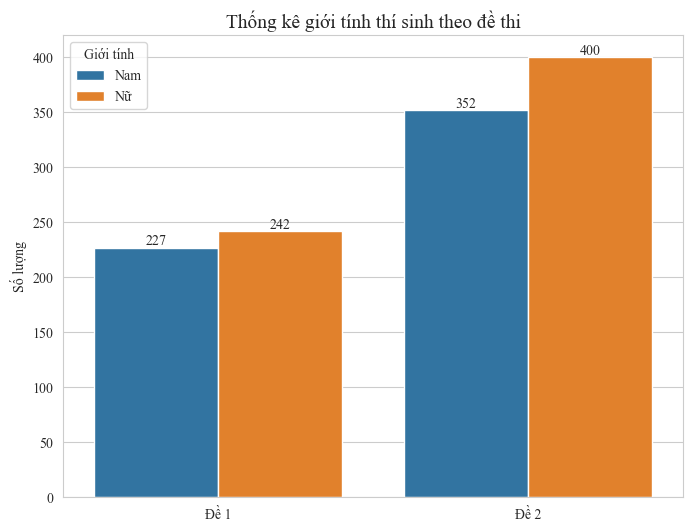

In [7]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.figure(figsize=(8, 6))
sns.countplot(data=gioi.melt(var_name='Đề', value_name='Giới tính'), x='Đề', hue='Giới tính')
plt.title('Thống kê giới tính thí sinh theo đề thi', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')
#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)


In [8]:
# lập thành bảng thống kê
gioi_counts = gioi.apply(pd.Series.value_counts).astype(int)
gioi_counts

,Đề 1,Đề 2
Nữ,242,400
Nam,227,352


In [9]:
df_chamdiem_1 = ip.ketQuaCham(df_dot1, da_1)
df_chamdiem_2 = ip.ketQuaCham(df_dot2, da_2)

In [10]:
order_kho = ['Rất dễ', 'Dễ', 'Tương đối dễ', 'Bình thường', 'Tương đối khó', 'Khó','Rất khó']
order_pb  = ['Kém', 'Chưa tốt', 'Chấp nhận được', 'Tương đối tốt', 'Tốt', 'Rất tốt','Quá tốt']
order_nhieu = ["Kém", "Yếu", "Bình thường", "Tốt"]

In [11]:
df_TV1, df_TA1, df_TO1, df_KH1 = ip.tach_phan(df_chamdiem_1)
df_TV2, df_TA2, df_TO2, df_KH2 = ip.tach_phan(df_chamdiem_2)

for data in [df_TV1, df_TA1, df_TO1, df_KH1, df_TV2, df_TA2, df_TO2, df_KH2]:
    data = ip.tinh_diem(data)

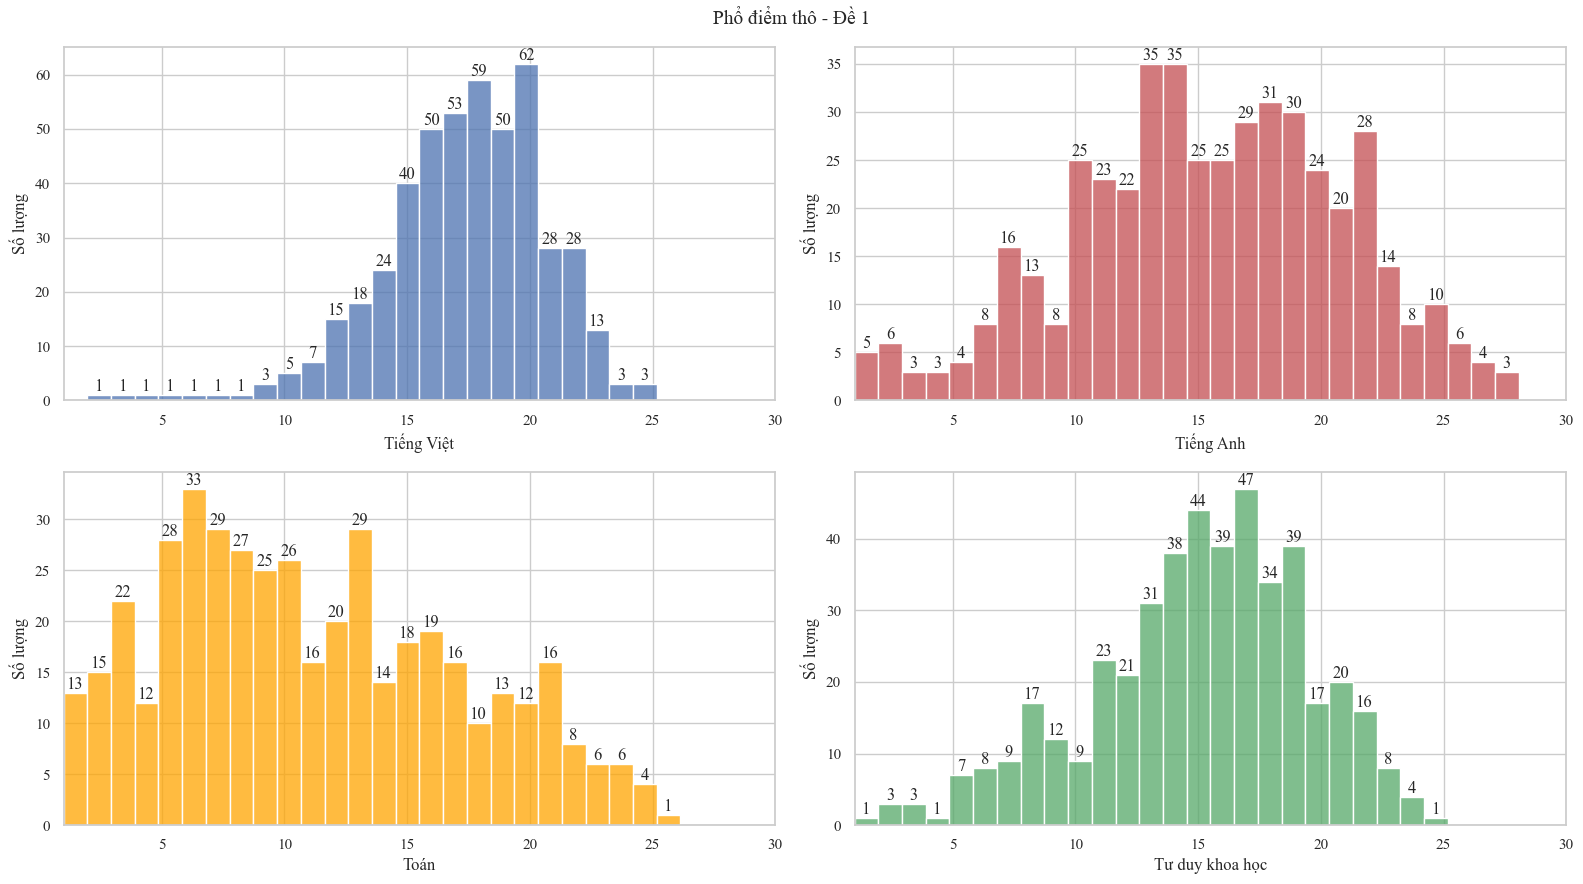

In [12]:
df_raw_1 = df_TV1[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)
    
df_raw_1 = df_raw_1.merge(df_TA1[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw_1 = df_raw_1.merge(df_TO1[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw_1 = df_raw_1.merge(df_KH1[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_raw_1, col_name='Raw', title='Phổ điểm thô - Đề 1', range=(1,30))

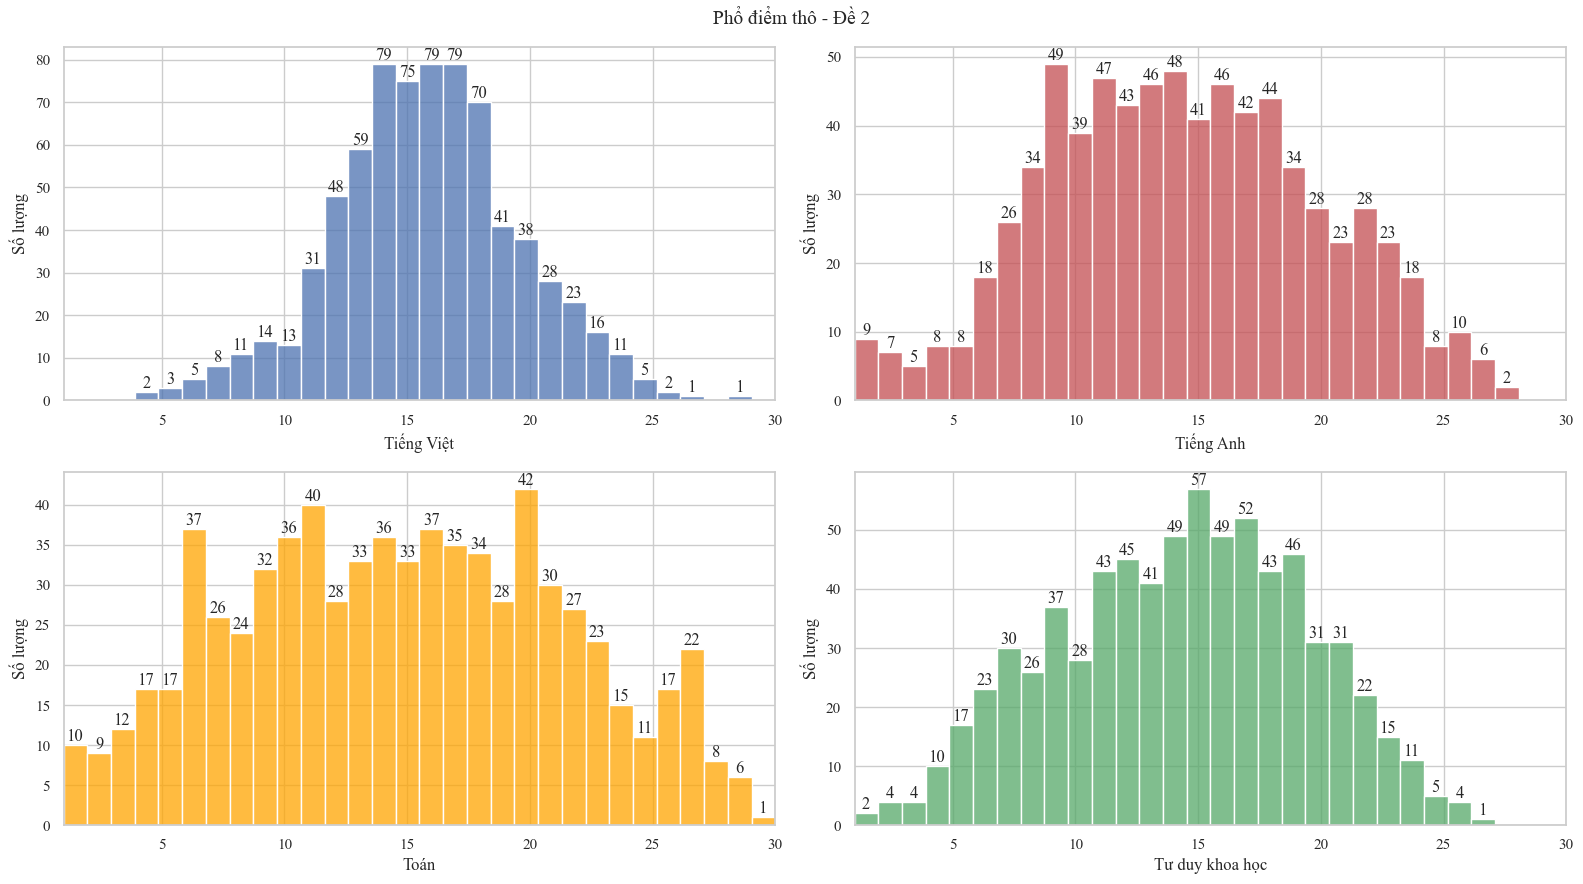

In [13]:
df_raw_2 = df_TV2[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw_2 = df_raw_2.merge(df_TA2[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw_2 = df_raw_2.merge(df_TO2[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw_2 = df_raw_2.merge(df_KH2[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_raw_2, col_name='Raw', title='Phổ điểm thô - Đề 2', range=(1,30))

In [14]:
df_raw_1[['RawTV', 'RawTA', 'RawTO', 'RawKH']].describe()

,RawTV,RawTA,RawTO,RawKH
count,469.000000,469.000000,469.000000,469.000000
mean,17.360341,15.202559,10.279318,14.484009
std,3.524670,5.924698,6.542826,5.292942
min,0.000000,0.000000,0.000000,0.000000
25%,15.000000,11.000000,5.000000,12.000000
50%,18.000000,15.000000,9.000000,15.000000
75%,20.000000,19.000000,15.000000,18.000000
max,25.000000,28.000000,26.000000,25.000000


In [15]:
df_raw_2[['RawTV', 'RawTA', 'RawTO', 'RawKH']].describe()

,RawTV,RawTA,RawTO,RawKH
count,752.000000,752.000000,752.000000,752.000000
mean,15.602394,14.105053,14.212766,13.748670
std,4.288236,5.954410,7.247568,5.763827
min,0.000000,0.000000,0.000000,0.000000
25%,13.000000,10.000000,9.000000,10.000000
50%,16.000000,14.000000,14.000000,14.000000
75%,18.000000,18.000000,20.000000,18.000000
max,29.000000,28.000000,30.000000,27.000000


In [16]:
rawtotal_1 = pd.Series(df_TV1['Raw'] + df_TA1['Raw'] + df_TO1['Raw'] + df_KH1['Raw'])
rawtotal_2 = pd.Series(df_TV2['Raw'] + df_TA2['Raw'] + df_TO2['Raw'] + df_KH2['Raw'])


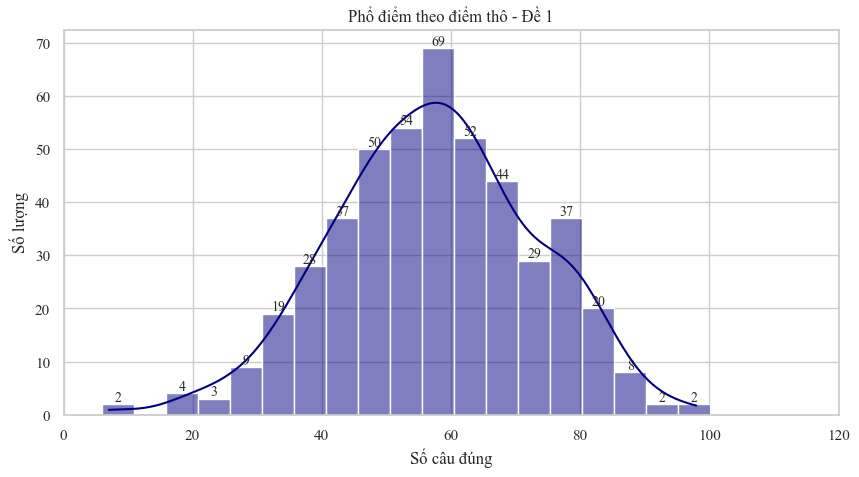

In [17]:
ip.plot_total(rawtotal_1, title='Phổ điểm theo điểm thô - Đề 1', range=(1,120), color='navy', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

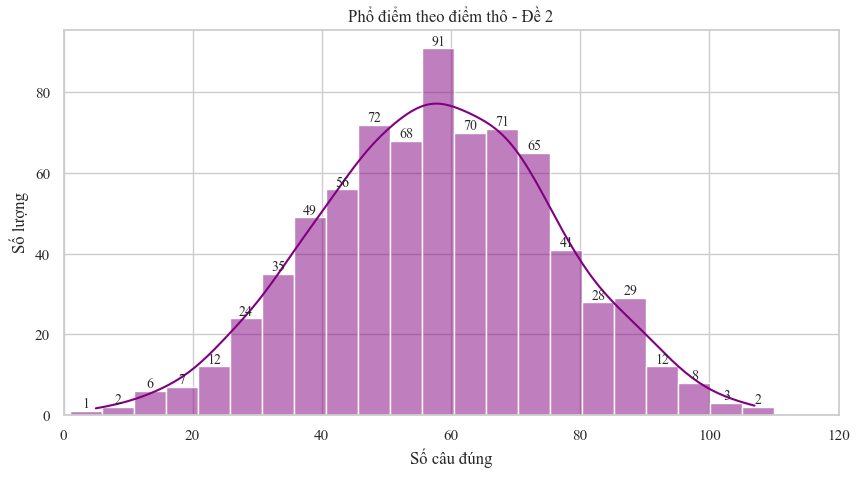

In [18]:
ip.plot_total(rawtotal_2, title='Phổ điểm theo điểm thô - Đề 2', range=(1,120), color='purple', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

In [19]:
diff_1, diff_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    diff_1 = pd.concat([diff_1, b], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    diff_2 = pd.concat([diff_2, b], axis=0)

diff_1 = diff_1.rename({0: 'CTT'}, axis=1)
diff_2 = diff_2.rename({0: 'CTT'}, axis=1)

In [20]:
diff_2.describe()

,CTT
count,120.000000
mean,0.492247
std,0.182863
min,0.084906
25%,0.374675
50%,0.461228
75%,0.613752
max,0.913747


In [21]:
def b_category(diff):
    if diff > 0.9:
        return 'Rất dễ'
    elif diff > 0.75:
        return 'Dễ'
    elif diff > 0.6:
        return 'Tương đối dễ'
    elif diff > 0.4:
        return 'Bình thường'
    elif diff > 0.25:
        return 'Tương đối khó'
    elif diff > 0.1:
        return 'Khó'
    else:
        return 'Rất khó'
    
diff_1['Phân loại'] = diff_1['CTT'].apply(b_category)
diff_2['Phân loại'] = diff_2['CTT'].apply(b_category)

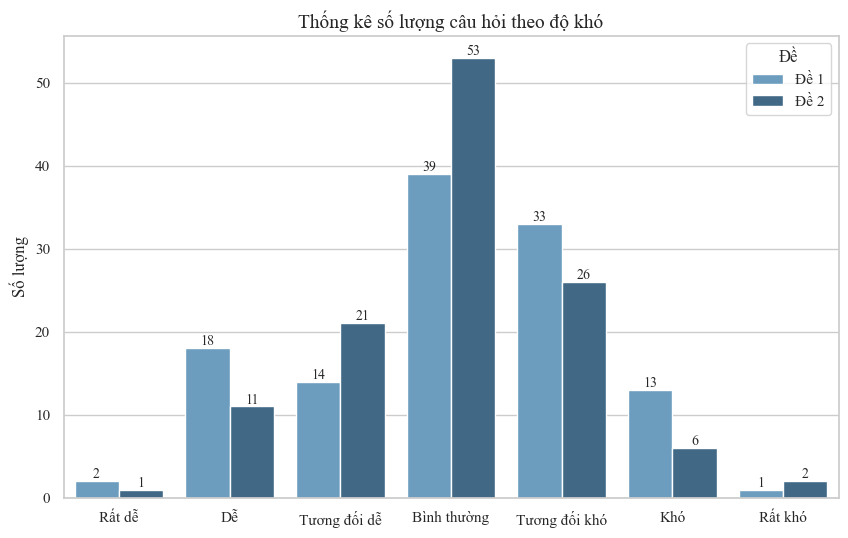

In [22]:
ip.plot_item(diff_1, diff_2, title='Thống kê số lượng câu hỏi theo độ khó', order=order_kho, palette='Blues_d', size=(10,6))

In [23]:
diff_1

,CTT,Phân loại
Cau1,0.784188,Dễ
Cau2,0.882479,Dễ
Cau3,0.831197,Dễ
Cau4,0.121795,Khó
Cau5,0.314103,Tương đối khó
...,...,...
Cau116,0.263274,Tương đối khó
Cau117,0.508850,Bình thường
Cau118,0.165929,Khó
Cau119,0.579646,Bình thường


In [24]:
diff_1['Phần thi'] = (
    diff_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

diff_2['Phần thi'] = (
    diff_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ khó xét theo từng phần thi của mỗi đợt')

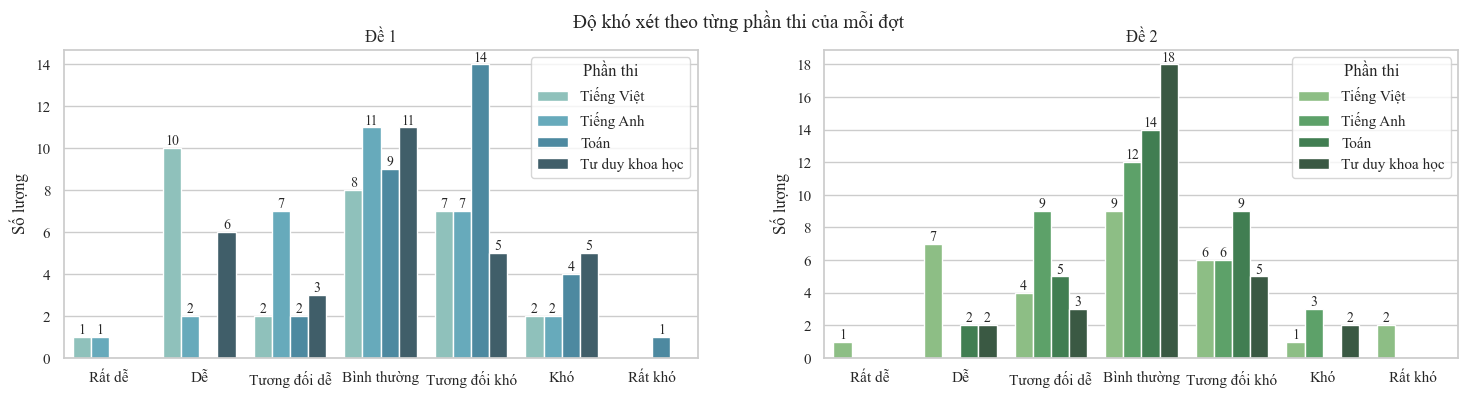

In [25]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 4))
sns.countplot(data=diff_1, x='Phân loại', palette='GnBu_d', ax=axes[0], hue='Phần thi', order=order_kho)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=diff_2, x='Phân loại', palette='YlGn_d', ax=axes[1], hue='Phần thi', order=order_kho)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 2))
axes[1].set_yticks(range(0, max_y2 + 1, 2))

plt.suptitle('Độ khó xét theo từng phần thi của mỗi đợt', fontsize=14)

C:\Users\Administra\AppData\Local\Temp\ipykernel_11000\1872895512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_1, x='Phần thi', y='CTT', palette='Blues_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_11000\1872895512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_2, x='Phần thi', y='CTT', palette='Purples_d', ax=axes[1])


Text(0.5, 0, '')

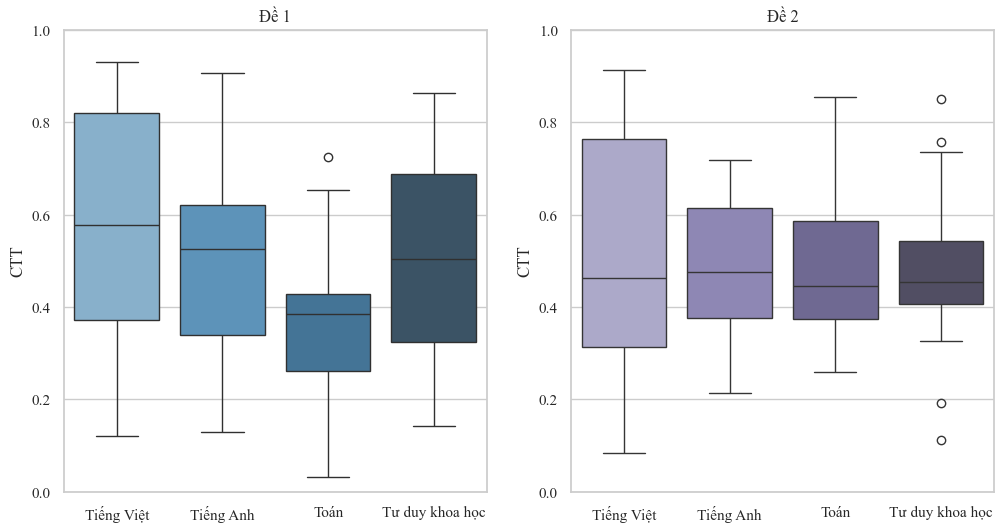

In [26]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=diff_1, x='Phần thi', y='CTT', palette='Blues_d', ax=axes[0])
axes[0].set_title('Đề 1')
axes[0].set_ylim(0,1)
axes[0].set_xlabel(None)
sns.boxplot(data=diff_2, x='Phần thi', y='CTT', palette='Purples_d', ax=axes[1])
axes[1].set_title('Đề 2')
axes[1].set_ylim(0,1)
axes[1].set_xlabel(None)
#plt.suptitle('Chênh lệch độ khó theo từng phần thi của mỗi đợt', fontsize=16)

In [27]:
disc_1, disc_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_1 = pd.concat([disc_1, a], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_2 = pd.concat([disc_2, a], axis=0)

disc_1 = disc_1.rename({0: 'D-Index'}, axis=1)
disc_2 = disc_2.rename({0: 'D-Index'}, axis=1)

In [28]:
def a_category(disc):
    if disc <= 0:
        return 'Kém'
    elif disc <= 0.20:
        return 'Chưa tốt'
    elif disc <= 0.40:
        return 'Chấp nhận được'
    elif disc <= 0.60:
        return 'Tương đối tốt'
    elif disc <= 0.80:
        return 'Tốt'
    elif disc <= 1.0:
        return 'Rất tốt'
    else:
        return 'Quá tốt'
    
disc_1['Phân loại'] = disc_1['D-Index'].apply(a_category)
disc_2['Phân loại'] = disc_2['D-Index'].apply(a_category)

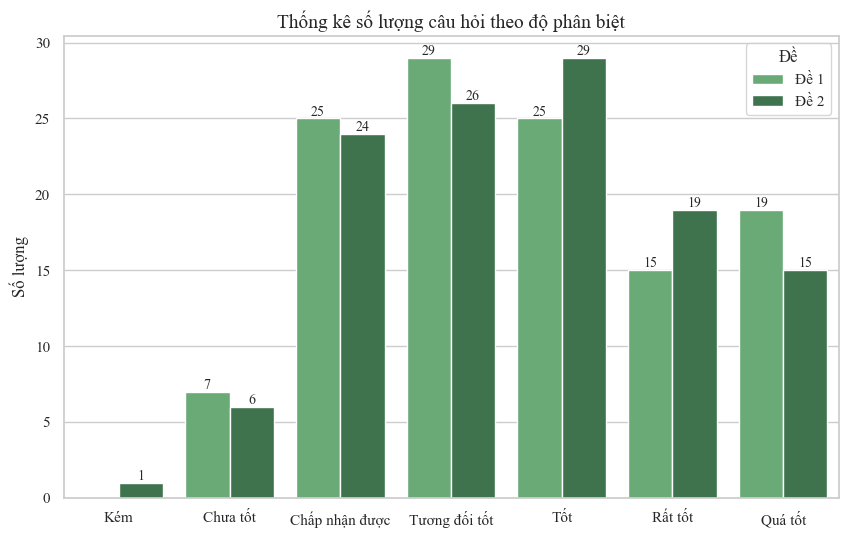

In [29]:
ip.plot_item(disc_1, disc_2, title='Thống kê số lượng câu hỏi theo độ phân biệt', order=order_pb, palette='Greens_d', size=(10,6))

In [30]:
disc_1['Phần thi'] = (
    disc_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

disc_2['Phần thi'] = (
    disc_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ phân biệt xét theo từng phần thi của mỗi đợt')

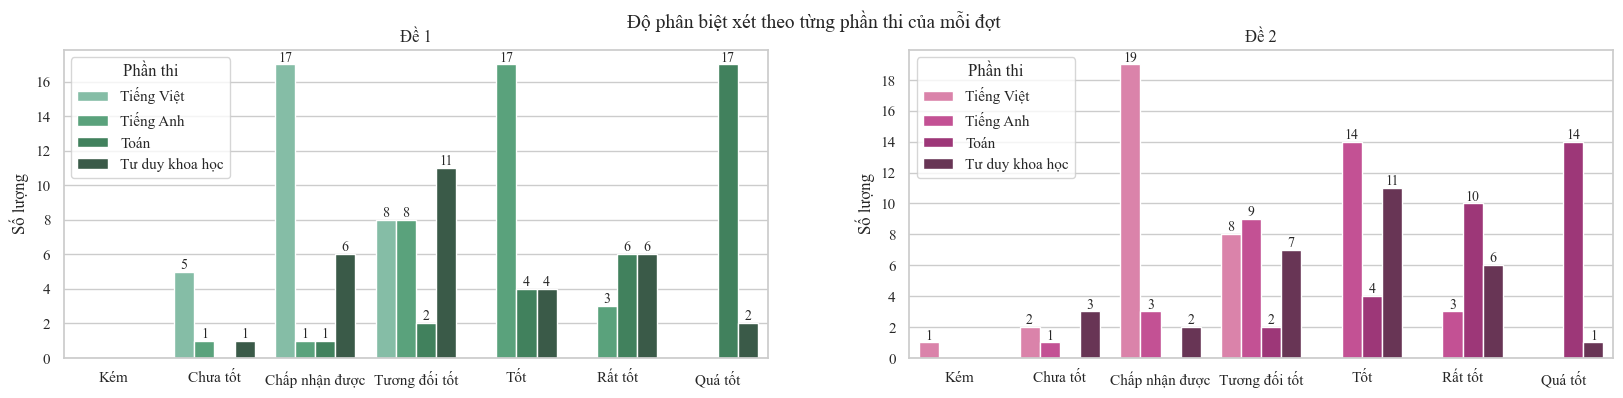

In [31]:
fig, axes = plt.subplots(ncols=2, figsize=(20, 4))
sns.countplot(data=disc_1, x='Phân loại', palette='BuGn_d', ax=axes[0], hue='Phần thi', order=order_pb)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=disc_2, x='Phân loại', palette='RdPu_d', ax=axes[1], hue='Phần thi', order=order_pb)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 2))
axes[1].set_yticks(range(0, max_y2 + 1, 2))

plt.suptitle('Độ phân biệt xét theo từng phần thi của mỗi đợt', fontsize=14)

C:\Users\Administra\AppData\Local\Temp\ipykernel_11000\799261752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=disc_1, x='Phần thi', y='D-Index', palette='viridis_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_11000\799261752.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=disc_2, x='Phần thi', y='D-Index', palette='plasma_d', ax=axes[1])


Text(0.5, 0, '')

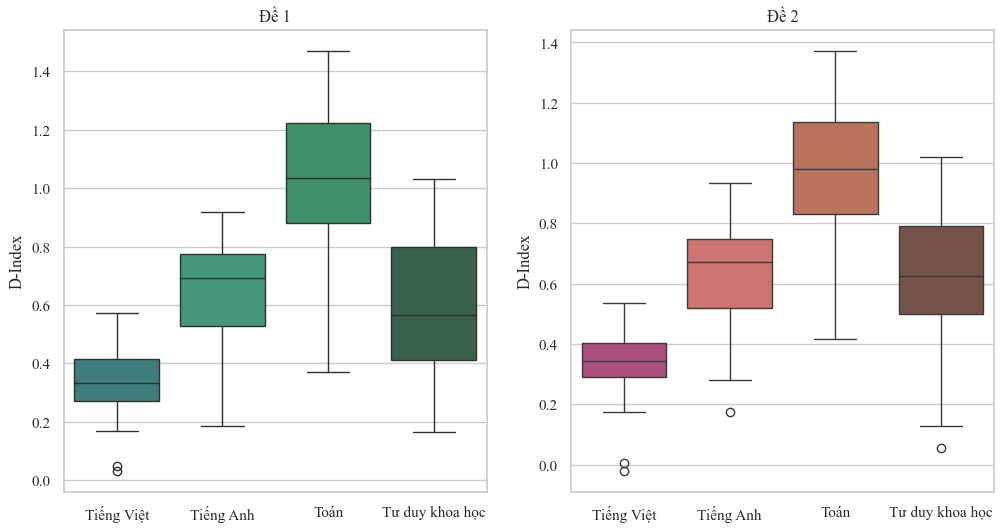

In [32]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=disc_1, x='Phần thi', y='D-Index', palette='viridis_d', ax=axes[0])
axes[0].set_title('Đề 1')
axes[0].set_xlabel(None)
sns.boxplot(data=disc_2, x='Phần thi', y='D-Index', palette='plasma_d', ax=axes[1])
axes[1].set_title('Đề 2')
axes[1].set_xlabel(None)
#plt.suptitle('Chênh lệch độ phân biệt theo từng phần thi của mỗi đợt', fontsize=16)

In [33]:
def do_nhieu(data: pd.DataFrame, chamdiem, answer: pd.DataFrame, start, end):
    # Merge 1 lần
    data = data.merge(chamdiem[['SBD', 'Raw', 'Null']], on='SBD', how='left')
    ans_row = answer.iloc[0]

    # DataFrame lưu kết quả tổng hợp
    df_all = pd.DataFrame(columns=["A", "B", "C", "D", "Null", "Ans"])

    # Lọc thí sinh hợp lệ
    valid = data[data['Null'] < 30]

    for stt in range(start, end + 1):
        std = valid['Raw'].std()
        cau_col = f"Cau{stt}"
        correct = ans_row[cau_col]
        n_total = valid.shape[0]
        pbcc_dict = {}

        for opt in ["A", "B", "C", "D"]:

            true_group  = valid.loc[valid[cau_col] == opt, 'Raw']
            false_group = valid.loc[valid[cau_col] != opt, 'Raw']
            if true_group.shape[0] == 0 or false_group.shape[0] == 0:
                pb = np.nan
            else:
                p = true_group.shape[0] / valid[cau_col].shape[0]
                pb = ctt.cal_pbcc(true_group, false_group, std, p)

            pbcc_dict[opt] = pb

        true_group = valid.loc[valid[cau_col].isna(), 'Raw']
        false_group = valid.loc[valid[cau_col].notna(), 'Raw']
        count = true_group.shape[0]
        percent = count / n_total if n_total > 0 else 0
        pbcc_dict["Null"] = ctt.cal_pbcc(true_group, false_group, std, percent) if count > 0 and false_group.shape[0] > 0 else np.nan
        # PBCC của đáp án đúng
        pbcc_ans = pbcc_dict.get(correct, np.nan)

        # Append 1 dòng vào df_all
        df_all.loc[f'Cau{stt}'] = [
            pbcc_dict["A"],
            pbcc_dict["B"],
            pbcc_dict["C"],
            pbcc_dict["D"],
            pbcc_dict["Null"],
            pbcc_ans
        ]

    return df_all


In [34]:
nhieu_1 = pd.concat([do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TV1, start=1, end=30),
                     do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TA1, start=31, end=60),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TO1, start=61, end=90),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_KH1, start=91, end=120),], axis=0)

In [35]:
nhieu_1

,A,B,C,D,Null,Ans
Cau1,-0.090698,-0.077724,0.145350,-0.050370,-0.155385,0.145350
Cau2,-0.077654,-0.164355,0.200580,-0.258847,-0.245800,0.200580
Cau3,0.023497,0.010622,0.020272,-0.064765,-0.040957,0.010622
Cau4,0.098663,0.055808,-0.015382,-0.074254,-0.445046,0.055808
Cau5,-0.137573,0.120029,-0.081774,0.114395,-0.386559,0.120029
...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,-0.411157,0.231577
Cau117,-0.146751,-0.147345,-0.014308,0.505123,-0.459603,0.505123
Cau118,-0.185613,-0.029800,0.259071,0.210703,-0.431992,0.210703
Cau119,-0.087406,0.508710,-0.103076,-0.149028,-0.440130,0.508710


In [36]:
nhieu_2 = pd.concat([
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TV2, start=1, end=30),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TA2, start=31, end=60),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TO2, start=61, end=90),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_KH2, start=91, end=120),
], axis=0)


In [37]:
nhieu_2

,A,B,C,D,Null,Ans
Cau1,-0.112050,-0.119164,-0.238992,0.372054,-0.082196,0.372054
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.167767,0.315619
Cau3,-0.072206,-0.204496,0.255094,-0.106073,-0.032604,0.255094
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.207271,0.265416
Cau5,-0.039716,-0.208780,-0.179729,0.298750,-0.146674,0.298750
...,...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,-0.259562,0.402168
Cau117,-0.198114,-0.057453,-0.174101,0.376236,-0.259836,0.376236
Cau118,-0.124422,-0.235191,-0.159096,0.557978,-0.381730,0.557978
Cau119,0.519316,-0.120816,-0.161446,-0.078337,-0.375110,0.519316


In [38]:
# hàm phân loại độ nhiễu câu hỏi
def label_distract(data):
    scale = 0
    for col in data.drop(columns='Ans').index:  # bỏ qua cột đáp án đúng
        if data[col] == data['Ans']:
            continue
        else:
            scale += (data[col]<0)
    if scale == 4:
        return "Tốt"
    elif scale == 3:
        return "Bình thường"
    elif scale == 2:
        return "Yếu"
    else:  
        return "Kém"

In [39]:
nhieu_1['Phân loại'] = nhieu_1.apply(label_distract, axis=1)
nhieu_1

,A,B,C,D,Null,Ans,Phân loại
Cau1,-0.090698,-0.077724,0.145350,-0.050370,-0.155385,0.145350,Tốt
Cau2,-0.077654,-0.164355,0.200580,-0.258847,-0.245800,0.200580,Tốt
Cau3,0.023497,0.010622,0.020272,-0.064765,-0.040957,0.010622,Yếu
Cau4,0.098663,0.055808,-0.015382,-0.074254,-0.445046,0.055808,Bình thường
Cau5,-0.137573,0.120029,-0.081774,0.114395,-0.386559,0.120029,Bình thường
...,...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,-0.411157,0.231577,Kém
Cau117,-0.146751,-0.147345,-0.014308,0.505123,-0.459603,0.505123,Tốt
Cau118,-0.185613,-0.029800,0.259071,0.210703,-0.431992,0.210703,Bình thường
Cau119,-0.087406,0.508710,-0.103076,-0.149028,-0.440130,0.508710,Tốt


In [40]:
nhieu_2['Phân loại'] = nhieu_2.apply(label_distract, axis=1)
nhieu_2

,A,B,C,D,Null,Ans,Phân loại
Cau1,-0.112050,-0.119164,-0.238992,0.372054,-0.082196,0.372054,Tốt
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.167767,0.315619,Bình thường
Cau3,-0.072206,-0.204496,0.255094,-0.106073,-0.032604,0.255094,Tốt
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.207271,0.265416,Bình thường
Cau5,-0.039716,-0.208780,-0.179729,0.298750,-0.146674,0.298750,Tốt
...,...,...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,-0.259562,0.402168,Tốt
Cau117,-0.198114,-0.057453,-0.174101,0.376236,-0.259836,0.376236,Tốt
Cau118,-0.124422,-0.235191,-0.159096,0.557978,-0.381730,0.557978,Tốt
Cau119,0.519316,-0.120816,-0.161446,-0.078337,-0.375110,0.519316,Tốt


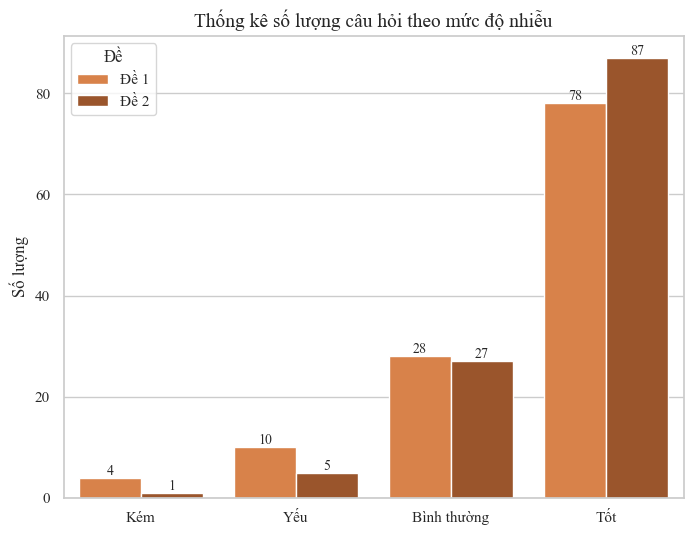

In [41]:
ip.plot_item(nhieu_1, nhieu_2, title='Thống kê số lượng câu hỏi theo mức độ nhiễu', order=order_nhieu, palette='Oranges_d', size=(8,6))

In [42]:
nhieu_1['Phần thi'] = (
    nhieu_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

nhieu_2['Phần thi'] = (
    nhieu_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ nhiễu xét theo từng phần thi của mỗi đợt')

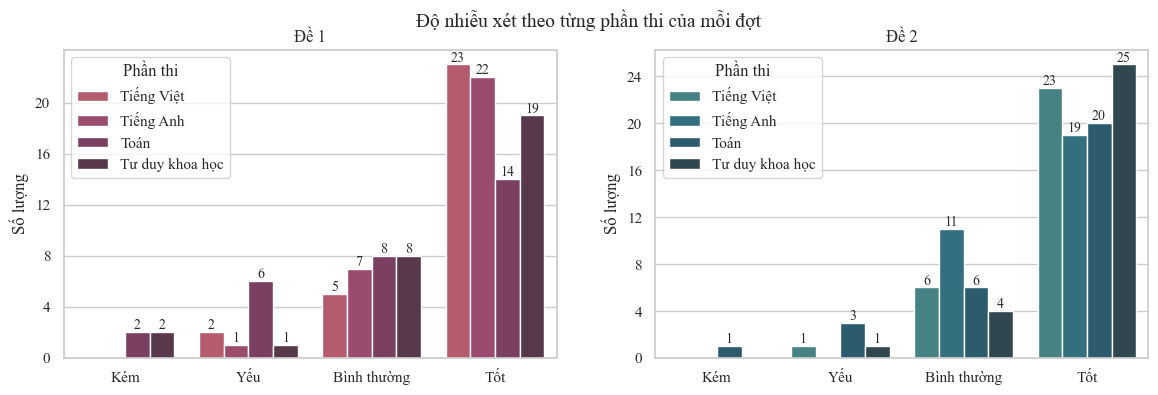

In [43]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
sns.countplot(data=nhieu_1, x='Phân loại', palette='flare_d', ax=axes[0], hue='Phần thi', order=order_nhieu)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=nhieu_2, x='Phân loại', palette='crest_d', ax=axes[1], hue='Phần thi', order=order_nhieu)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 4))
axes[1].set_yticks(range(0, max_y2 + 1, 4))

plt.suptitle('Độ nhiễu xét theo từng phần thi của mỗi đợt', fontsize=14)

In [44]:
diff_1['CTT']

Cau1      0.784188
Cau2      0.882479
Cau3      0.831197
Cau4      0.121795
Cau5      0.314103
            ...   
Cau116    0.263274
Cau117    0.508850
Cau118    0.165929
Cau119    0.579646
Cau120    0.422566
Name: CTT, Length: 120, dtype: float64

In [45]:
item_ctt_1 = pd.concat([
    diff_1.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_1.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_1.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

item_ctt_2 = pd.concat([
    diff_2.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_2.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_2.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

In [46]:
item_ctt_1, item_ctt_2

(             CTT         Độ khó   D-Index   Độ phân biệt         A         B  \
 Cau1    0.784188             Dễ  0.174603       Chưa tốt -0.090698 -0.077724   
 Cau2    0.882479             Dễ  0.182540       Chưa tốt -0.077654 -0.164355   
 Cau3    0.831197             Dễ  0.031746       Chưa tốt  0.023497  0.010622   
 Cau4    0.121795            Khó  0.047619       Chưa tốt  0.098663  0.055808   
 Cau5    0.314103  Tương đối khó  0.166667       Chưa tốt -0.137573  0.120029   
 ...          ...            ...       ...            ...       ...       ...   
 Cau116  0.263274  Tương đối khó  0.590164  Tương đối tốt  0.093254  0.231577   
 Cau117  0.508850    Bình thường  1.032787        Quá tốt -0.146751 -0.147345   
 Cau118  0.165929            Khó  0.557377  Tương đối tốt -0.185613 -0.029800   
 Cau119  0.579646    Bình thường  0.975410        Rất tốt -0.087406  0.508710   
 Cau120  0.422566    Bình thường  0.885246        Rất tốt -0.105607  0.394653   
 
                C         

In [47]:
import textwrap

def wrap_labels(ax, width=10):
    ax.set_xticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_xticklabels()]
    )
    ax.set_yticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_yticklabels()]
    )
    
def heatmap_pair(df, col1, col2, title, cmap, order1=None, order2=None, ax=None):
    if order1 is not None:
        df[col1] = pd.Categorical(df[col1], categories=order1, ordered=True)
    if order2 is not None:
        df[col2] = pd.Categorical(df[col2], categories=order2, ordered=True)

    ct = pd.crosstab(df[col1], df[col2])

    #plt.figure(figsize=(6, 6))
    ax = sns.heatmap(ct, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax)

    ax.set_title(title)
    plt.xlabel(col2)
    plt.ylabel(col1)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=0) 
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    # Tự động xuống dòng
    wrap_labels(ax, width=8)

    plt.tight_layout()

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 1')

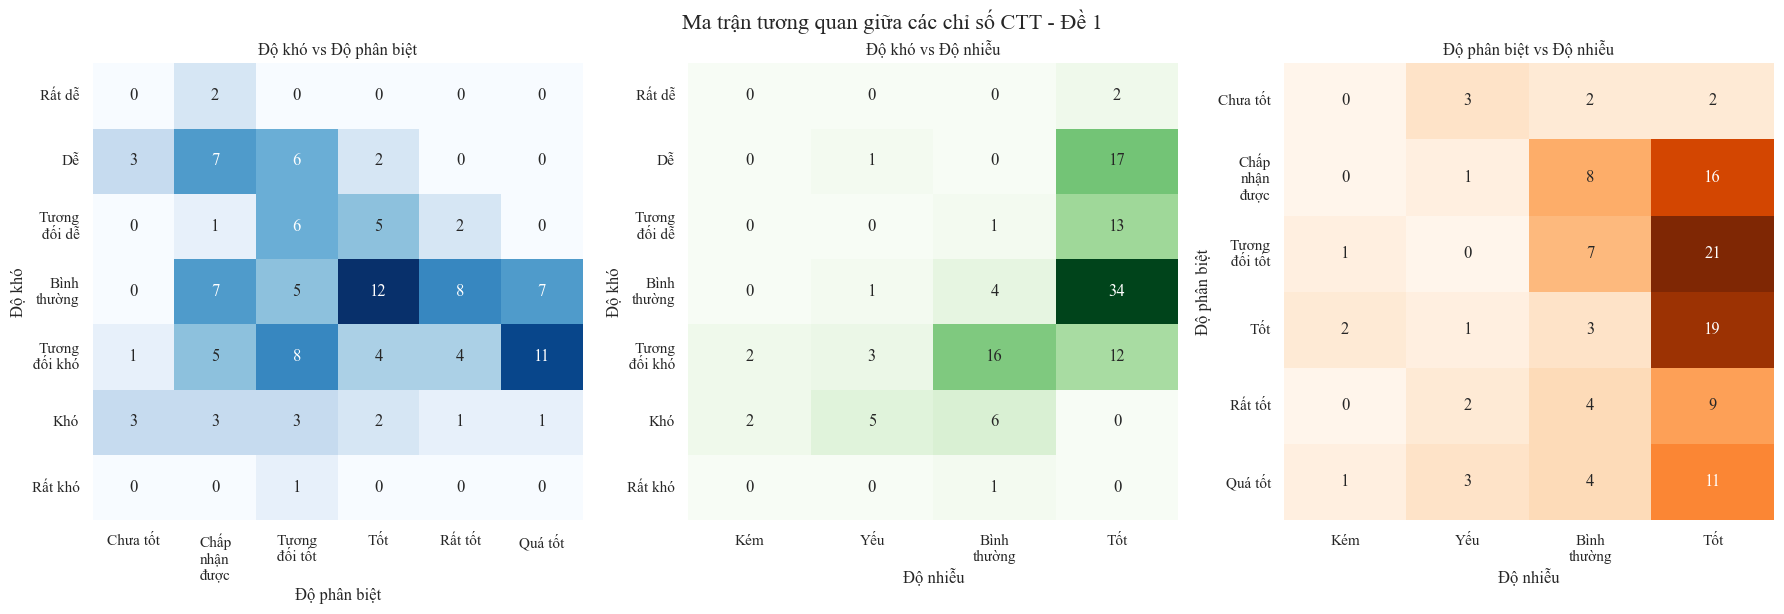

In [48]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_1, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_1, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_1, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 1', fontsize=16, y=1.02)

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 2')

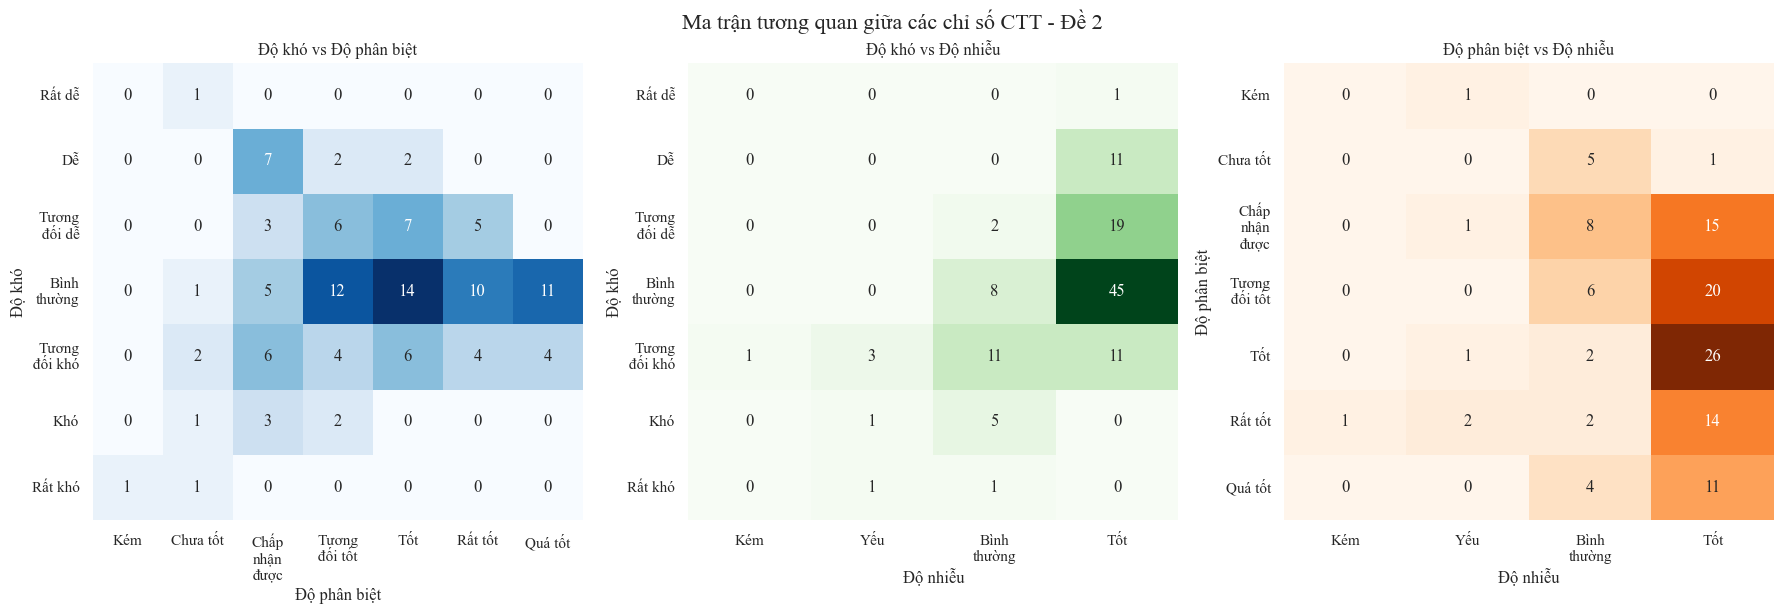

In [49]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_2, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_2, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_2, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 2', fontsize=16, y=1.02)

In [50]:
a_init_1 = nhieu_1['Ans'].apply(irt.cal_disc)
a_init_2 = nhieu_2['Ans'].apply(irt.cal_disc)
b_init_1 = diff_1['CTT'].apply(irt.cal_diff)
b_init_2 = diff_2['CTT'].apply(irt.cal_diff)

In [51]:
def run_irt_series(series_list):
    a_est_all, b_est_all = [], []

    for df_original, end_idx, name in series_list:

        df = df_original.copy()
        valid_mask = (df["Raw"] > 0) & (df["Raw"] < 30)

        # Chỉ lấy dữ liệu hợp lệ để chạy IRT (bỏ qua các trường hợp đúng/sai hết)
        df_valid = df[valid_mask]
        U = df_valid.drop(columns=['SBD', 'MaDe', 'Gioi', 'Raw', 'Null']).to_numpy()

        # a_init = a_init_all.iloc[end_idx-30:end_idx]
        # b_init = b_init_all.iloc[end_idx-30:end_idx]

        # MMLE
        a_est, b_est = irt.mmle(U=U, name=name, max_iter=100)

        # Tính theta cho dữ liệu hợp lệ
        item_params = list(zip(a_est, b_est))
        theta_valid = irt.theta_estimate(U, item_params=item_params)

        # Tạo mảng theta cuối cùng cho toàn bộ học sinh
        theta = np.empty(len(df))

        # Gán theta tính bằng IRT cho nhóm hợp lệ
        theta[valid_mask.to_numpy()] = theta_valid

        # các trường hợp đúng hoặc sai hết
        theta[df["Raw"] == 0] = -6
        theta[df["Raw"] == 30] = 6

        # Gán theta vào DataFrame
        df_original["Theta"] = theta

        a_est_all.extend(a_est)
        b_est_all.extend(b_est)

    return a_est_all, b_est_all


# --- Chạy cho bộ đề 1 ---
series_1 = [[df_TV1, 30, 'TV'], [df_TA1, 60, 'TA'], [df_TO1, 90, 'TO'], [df_KH1, 120, 'KH']]
a_est_1, b_est_1 = run_irt_series(series_1)

# --- Chạy cho bộ đề 2 ---
series_2 = [[df_TV2, 30, 'TV'], [df_TA2, 60, 'TA'], [df_TO2, 90, 'TO'], [df_KH2, 120, 'KH']]
a_est_2, b_est_2 = run_irt_series(series_2)


Start TV: N=468, J=30, K=81
Start TA: N=463, J=30, K=81
Start TO: N=438, J=30, K=81
Start KH: N=452, J=30, K=81
Start TV: N=742, J=30, K=81
Start TA: N=740, J=30, K=81
Start TO: N=725, J=30, K=81
Start KH: N=726, J=30, K=81


In [52]:
item_irt_1 = pd.DataFrame({
    'a': a_est_1,   
    'b': b_est_1}, index=nhieu_1.index)
item_irt_2 = pd.DataFrame({
    'a': a_est_2,
    'b': b_est_2}, index=nhieu_2.index)

In [53]:
item_irt_1, item_irt_2

(               a         b
 Cau1    0.703155 -1.076755
 Cau2    1.172389 -1.158103
 Cau3    0.735018 -1.233020
 Cau4    0.812304  1.567767
 Cau5    0.357126  1.267069
 ...          ...       ...
 Cau116  0.285981  1.215192
 Cau117  0.954264 -0.432678
 Cau118  0.642136  1.287131
 Cau119  0.794422 -0.750932
 Cau120  0.554443 -0.076139
 
 [120 rows x 2 columns],
                a         b
 Cau1    0.586772  0.192429
 Cau2    0.501738 -0.626656
 Cau3    0.386996 -0.974681
 Cau4    0.652807  1.129418
 Cau5    0.453533  0.514580
 ...          ...       ...
 Cau116  0.498263 -0.080856
 Cau117  0.373077 -0.033725
 Cau118  1.071104 -0.592463
 Cau119  0.939731 -0.099126
 Cau120  0.614875  0.137439
 
 [120 rows x 2 columns])

In [54]:
def cal_true_score(series_list, item_irt):
    cau_cols = series_list.columns[series_list.columns.str.contains("^Cau", regex=True)]

    series_list["True"] = series_list.apply(
        lambda row: irt.true_score(
            theta=row["Theta"],
            data=row[cau_cols],
            item_params=item_irt.loc[cau_cols]  # lấy đúng parameters theo câu
        ),
        axis=1
    )

In [55]:
for df_list in [df_TV1, df_TA1, df_TO1, df_KH1]:
    cal_true_score(df_list, item_irt_1)

for df_list in [df_TV2, df_TA2, df_TO2, df_KH2]:
    cal_true_score(df_list, item_irt_2)

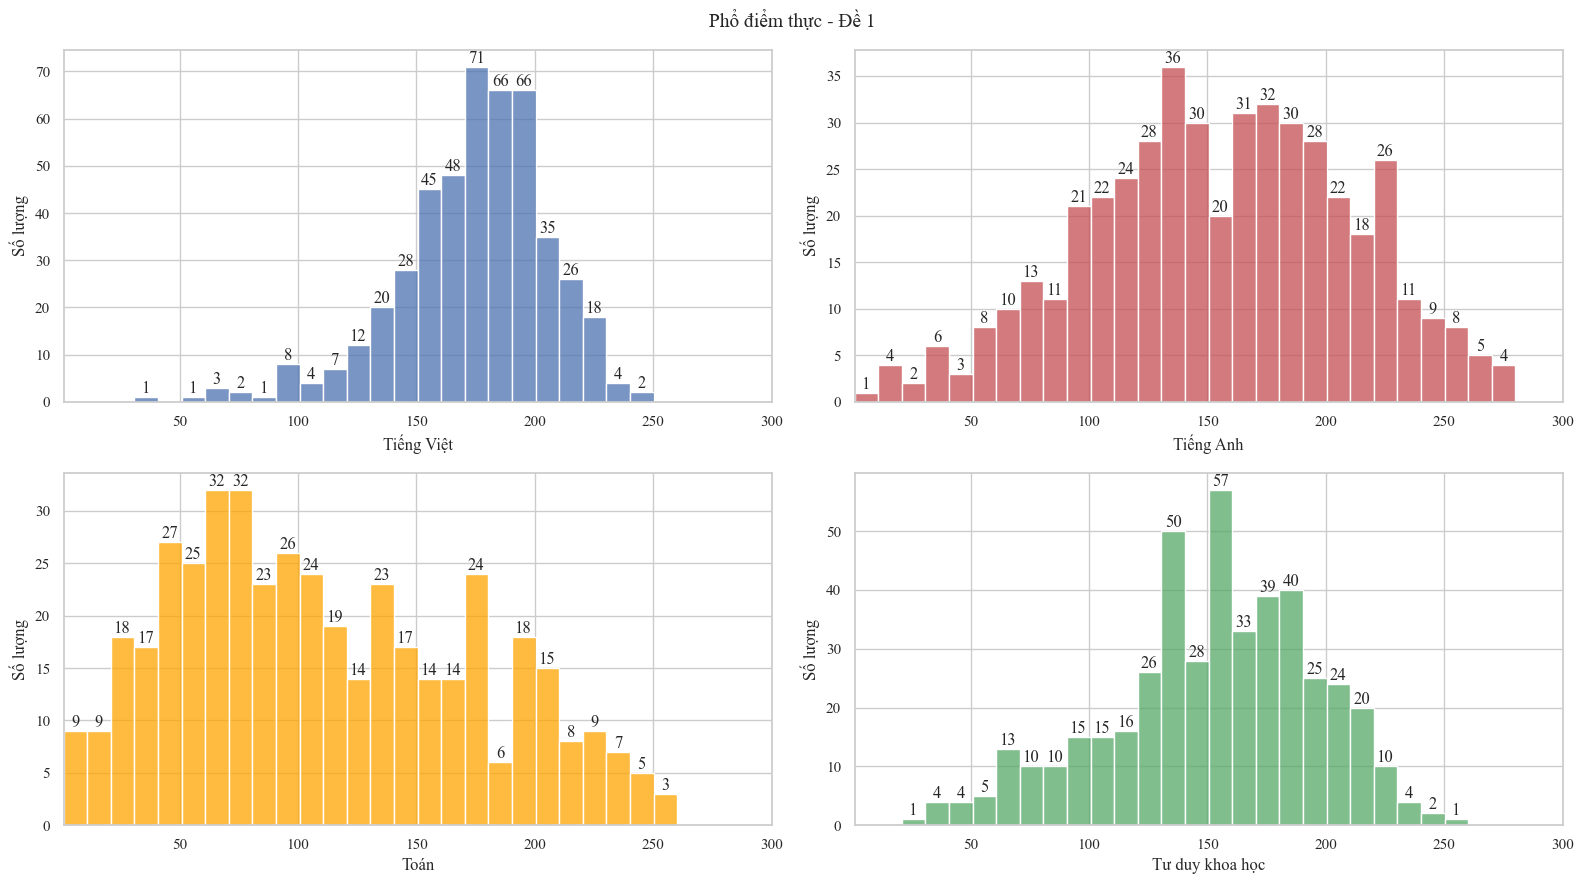

In [56]:
df_true_1 = df_TV1[['SBD', 'True']].copy().rename({'True': 'TrueTV'}, axis=1)

df_true_1 = df_true_1.merge(df_TA1[['SBD', 'True']].rename({'True': 'TrueTA'}, axis=1), on='SBD', how='outer')
df_true_1 = df_true_1.merge(df_TO1[['SBD', 'True']].rename({'True': 'TrueTO'}, axis=1), on='SBD', how='outer')
df_true_1 = df_true_1.merge(df_KH1[['SBD', 'True']].rename({'True': 'TrueKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_true_1, col_name='True', title='Phổ điểm thực - Đề 1', range=(1,300))

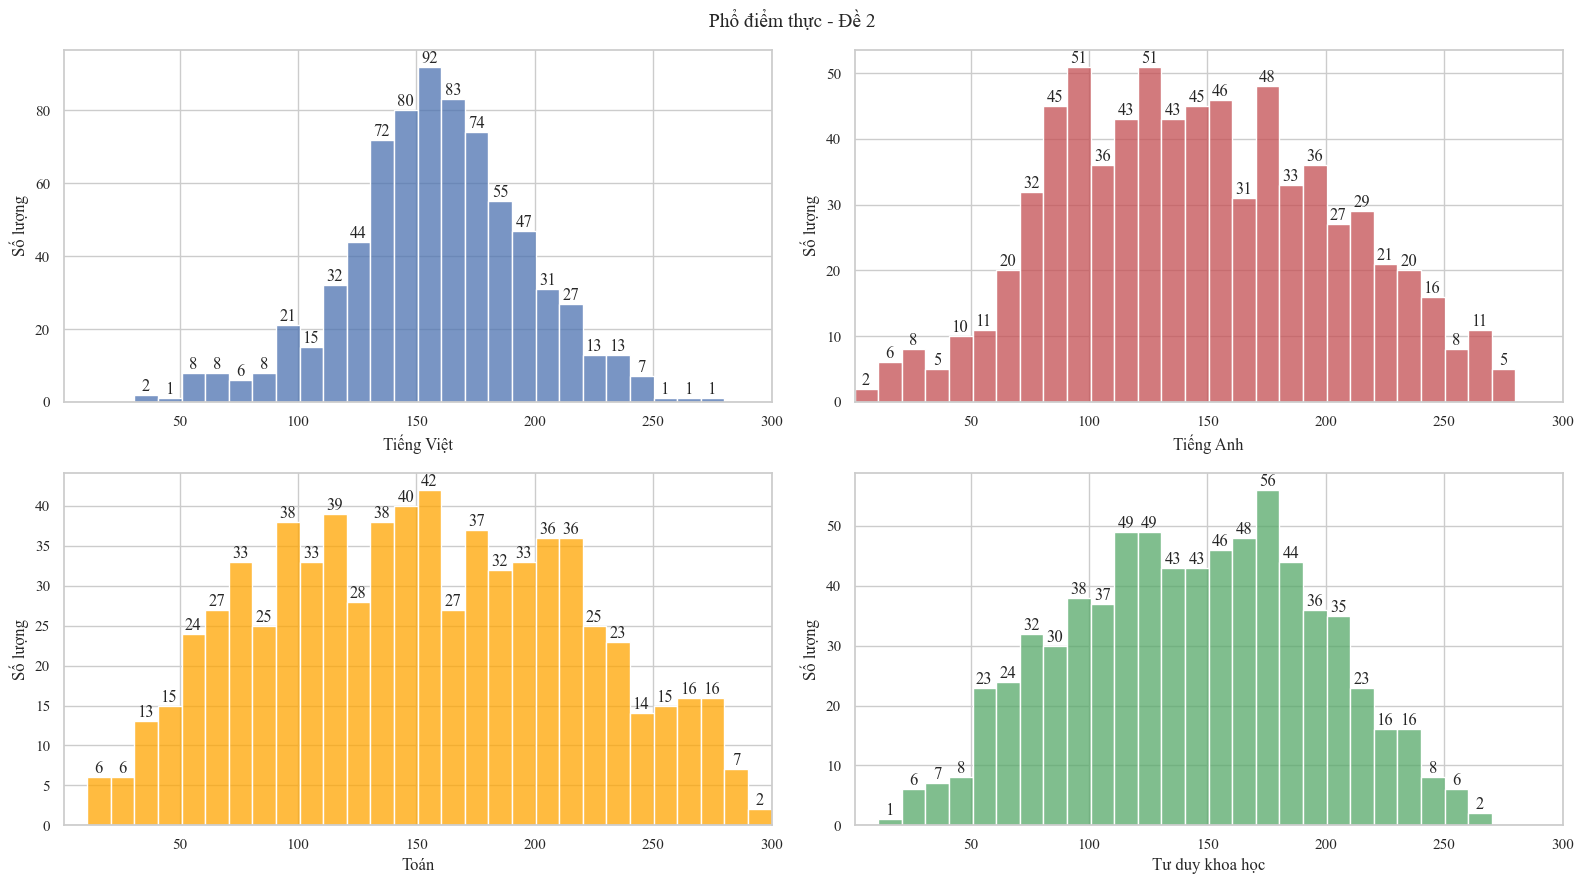

In [57]:
df_true_2 = df_TV2[['SBD', 'True']].copy().rename({'True': 'TrueTV'}, axis=1)

df_true_2 = df_true_2.merge(df_TA2[['SBD', 'True']].rename({'True': 'TrueTA'}, axis=1), on='SBD', how='outer')
df_true_2 = df_true_2.merge(df_TO2[['SBD', 'True']].rename({'True': 'TrueTO'}, axis=1), on='SBD', how='outer')
df_true_2 = df_true_2.merge(df_KH2[['SBD', 'True']].rename({'True': 'TrueKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_true_2, col_name='True', title='Phổ điểm thực - Đề 2', range=(1,300))

In [58]:
df_true_1[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].describe()

,TrueTV,TrueTA,TrueTO,TrueKH
count,469.000000,469.000000,469.000000,469.000000
mean,174.272921,152.921109,103.831557,146.646055
std,33.225244,58.310913,66.255361,51.613688
min,0.000000,0.000000,0.000000,0.000000
25%,157.000000,114.000000,54.000000,124.000000
50%,178.000000,156.000000,95.000000,155.000000
75%,196.000000,196.000000,157.000000,182.000000
max,246.000000,279.000000,260.000000,253.000000


In [59]:
df_true_2[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].describe()

,TrueTV,TrueTA,TrueTO,TrueKH
count,752.000000,752.000000,752.00000,752.000000
mean,156.292553,141.932181,146.12500,137.986702
std,41.793890,59.901334,70.12031,57.411124
min,0.000000,0.000000,0.00000,0.000000
25%,135.000000,97.000000,94.75000,99.000000
50%,159.000000,140.500000,148.00000,142.000000
75%,181.000000,186.000000,201.00000,180.000000
max,275.000000,277.000000,300.00000,267.000000


In [63]:
df_true_1['Total_True'] = df_true_1[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].sum(axis=1)
df_true_2['Total_True'] = df_true_2[['TrueTV', 'TrueTA', 'TrueTO', 'TrueKH']].sum(axis=1)

In [64]:
def plot_total_with_stats(df_true, title, color):
    total = df_true.shape[0]
    max = df_true['Total_True'].max()
    min = df_true['Total_True'].min()
    mean = df_true['Total_True'].mean()
    std = df_true['Total_True'].std()
    median = df_true['Total_True'].median()

    ip.plot_total(
        df_true['Total_True'],
        title=title,
        range=(1,1200),
        color=color,
        xlabel='Điểm thực',
        ylabel='Số lượng',
        lim=(0, 1200)
    )
    stats_text = f"Tổng số thí sinh dự thi: {total}\nCao nhất: {max}\nThấp nhất: {min:.0f}\nTrung bình: {np.round(mean,2)}\nTrung vị: {np.round(median,2)}\nĐộ lệch chuẩn: {np.round(std,2)}"
    # Thêm một mục "giả" vào legend để hiển thị chú thích kết quả thống kê
    plt.plot([], ' ', label=stats_text)
    plt.legend(loc='upper left', fontsize=12)


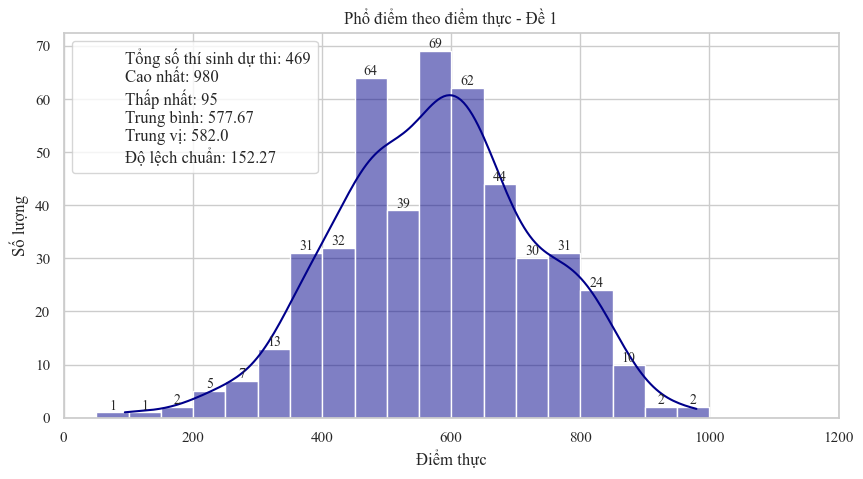

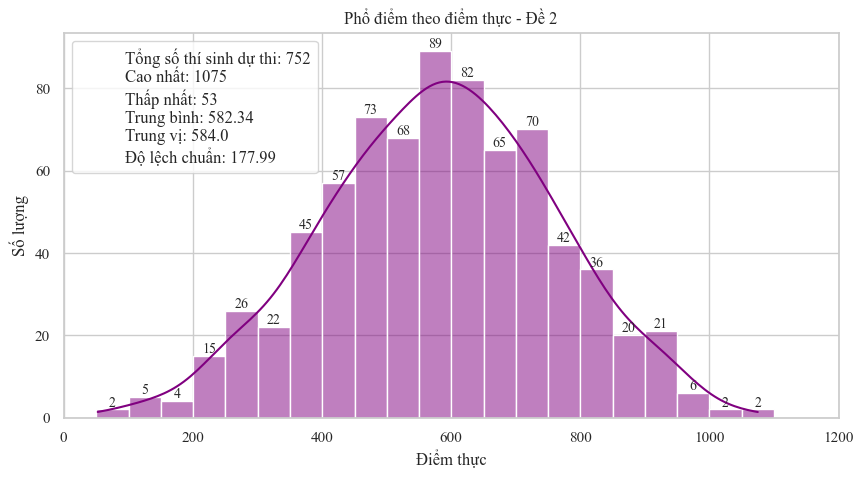

In [65]:
plot_total_with_stats(df_true_1, title='Phổ điểm theo điểm thực - Đề 1', color='darkblue')
plot_total_with_stats(df_true_2, title='Phổ điểm theo điểm thực - Đề 2', color='purple')

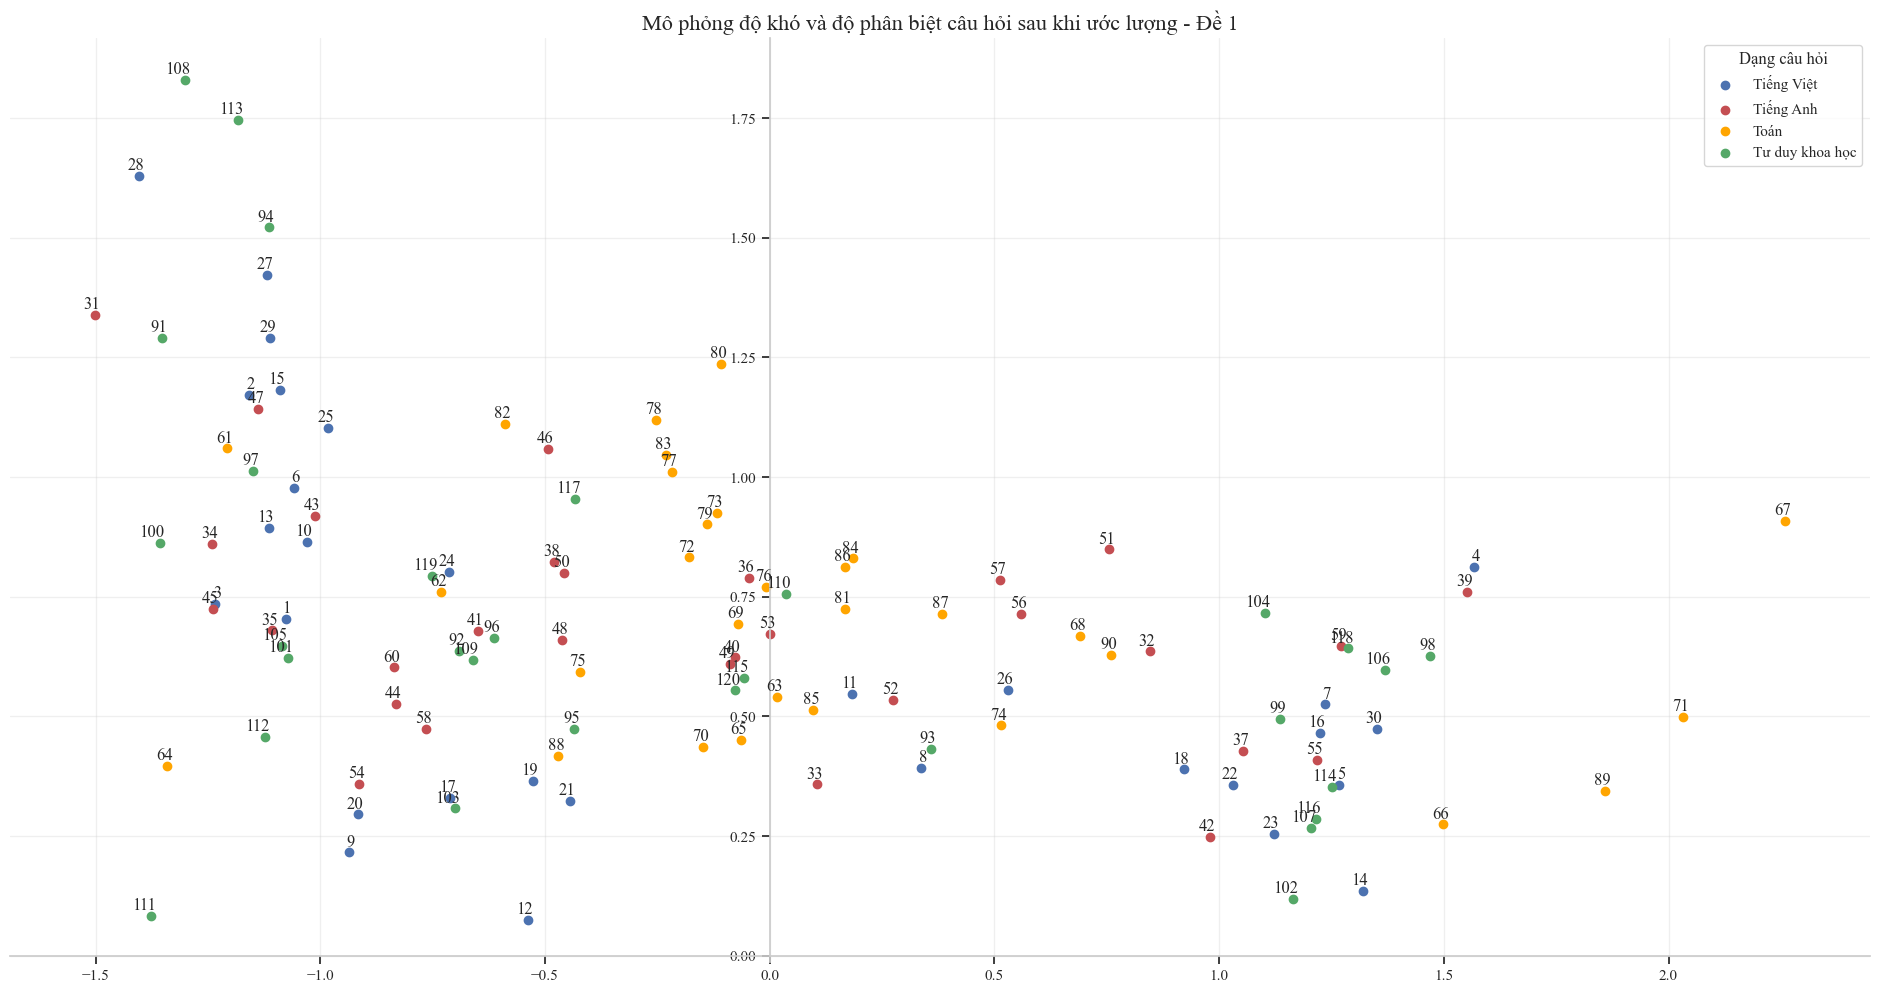

In [60]:
ip.oxy_item(item_irt_1, title='Mô phỏng độ khó và độ phân biệt câu hỏi sau khi ước lượng - Đề 1')

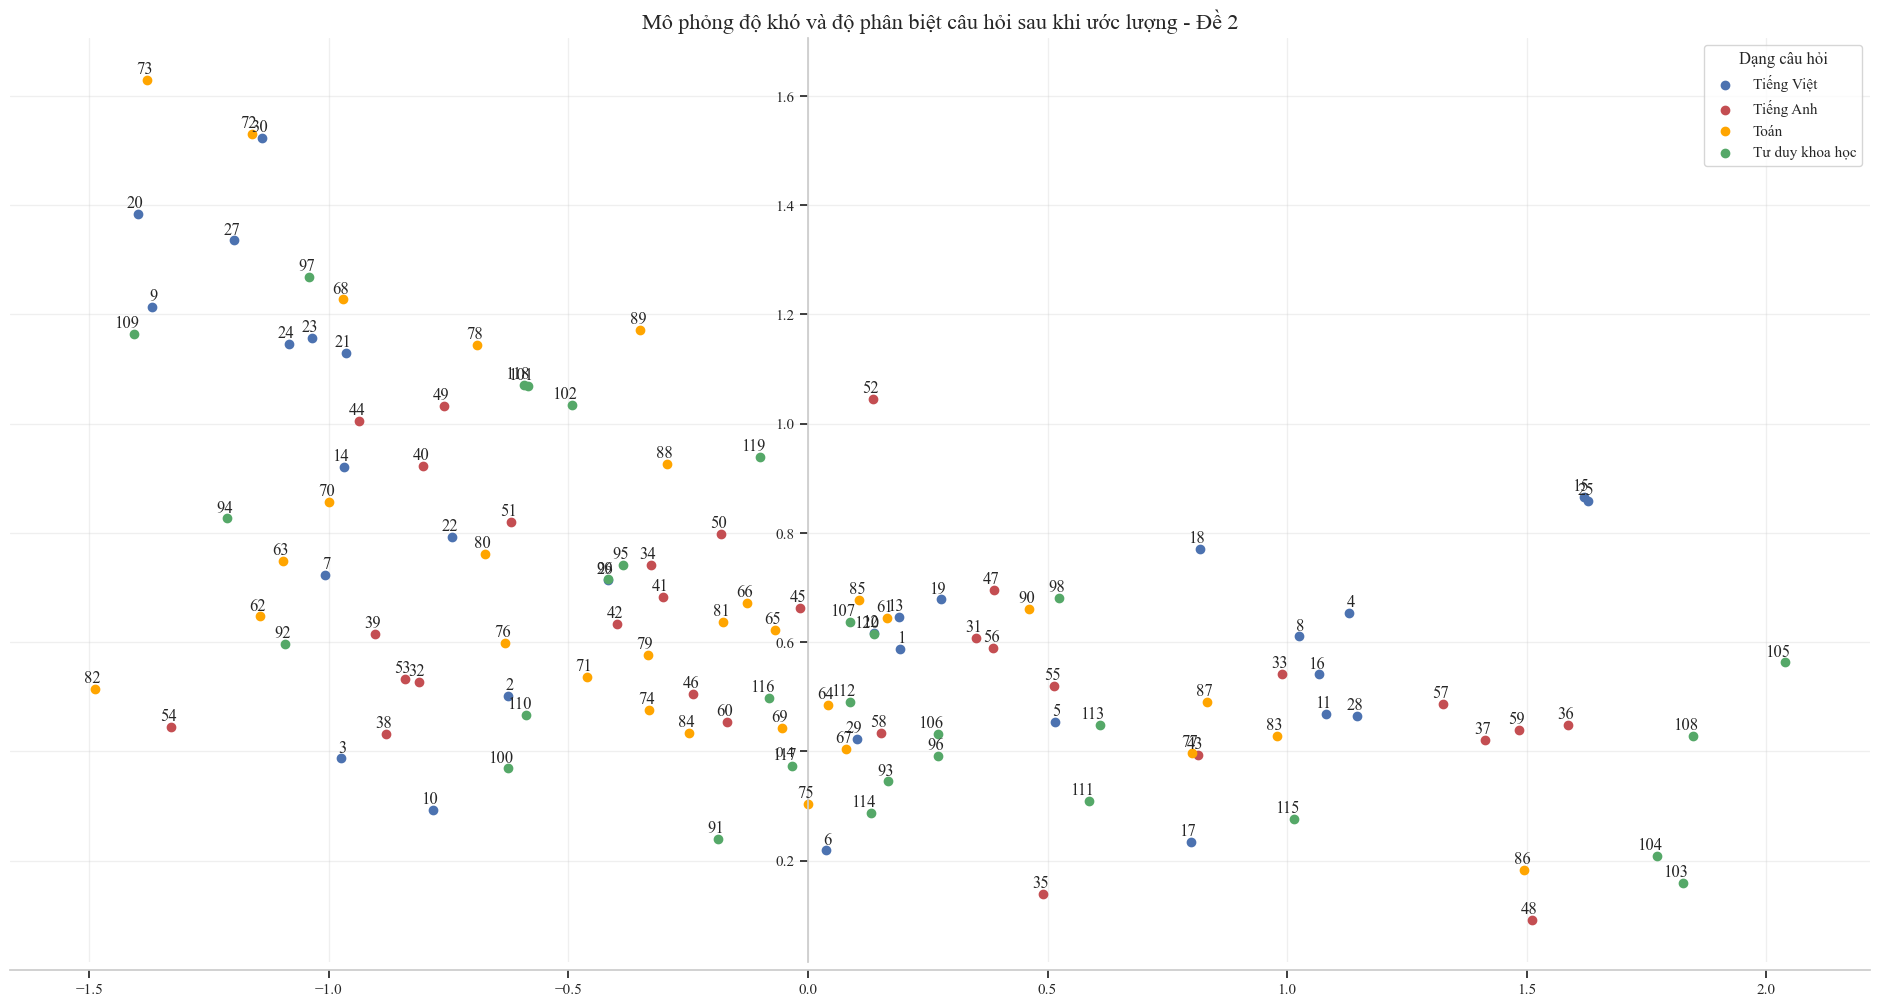

In [61]:
ip.oxy_item(item_irt_2, title='Mô phỏng độ khó và độ phân biệt câu hỏi sau khi ước lượng - Đề 2')

In [74]:
def drawTTC(df_TV, df_TA, df_TO, df_KH, title: str):
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(20, 12))

    # ------------------------- chỉnh trục -------------------------
    for ax in axes.flat:
        ax.spines['left'].set_position('zero')
        ax.spines['bottom'].set_position('zero')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')


    # ---------------------- gọi các subplot ----------------------
    ip.plot_one(axes[0][0], df_TV["Theta"], df_TV["Raw"], "Tiếng Việt", color='b')
    ip.plot_one(axes[0][1], df_TA["Theta"], df_TA["Raw"], "Tiếng Anh", color='r')
    ip.plot_one(axes[1][0], df_TO["Theta"], df_TO["Raw"], "Toán", color='y')
    ip.plot_one(axes[1][1], df_KH["Theta"], df_KH["Raw"], "Tư duy khoa học", color='g')

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()


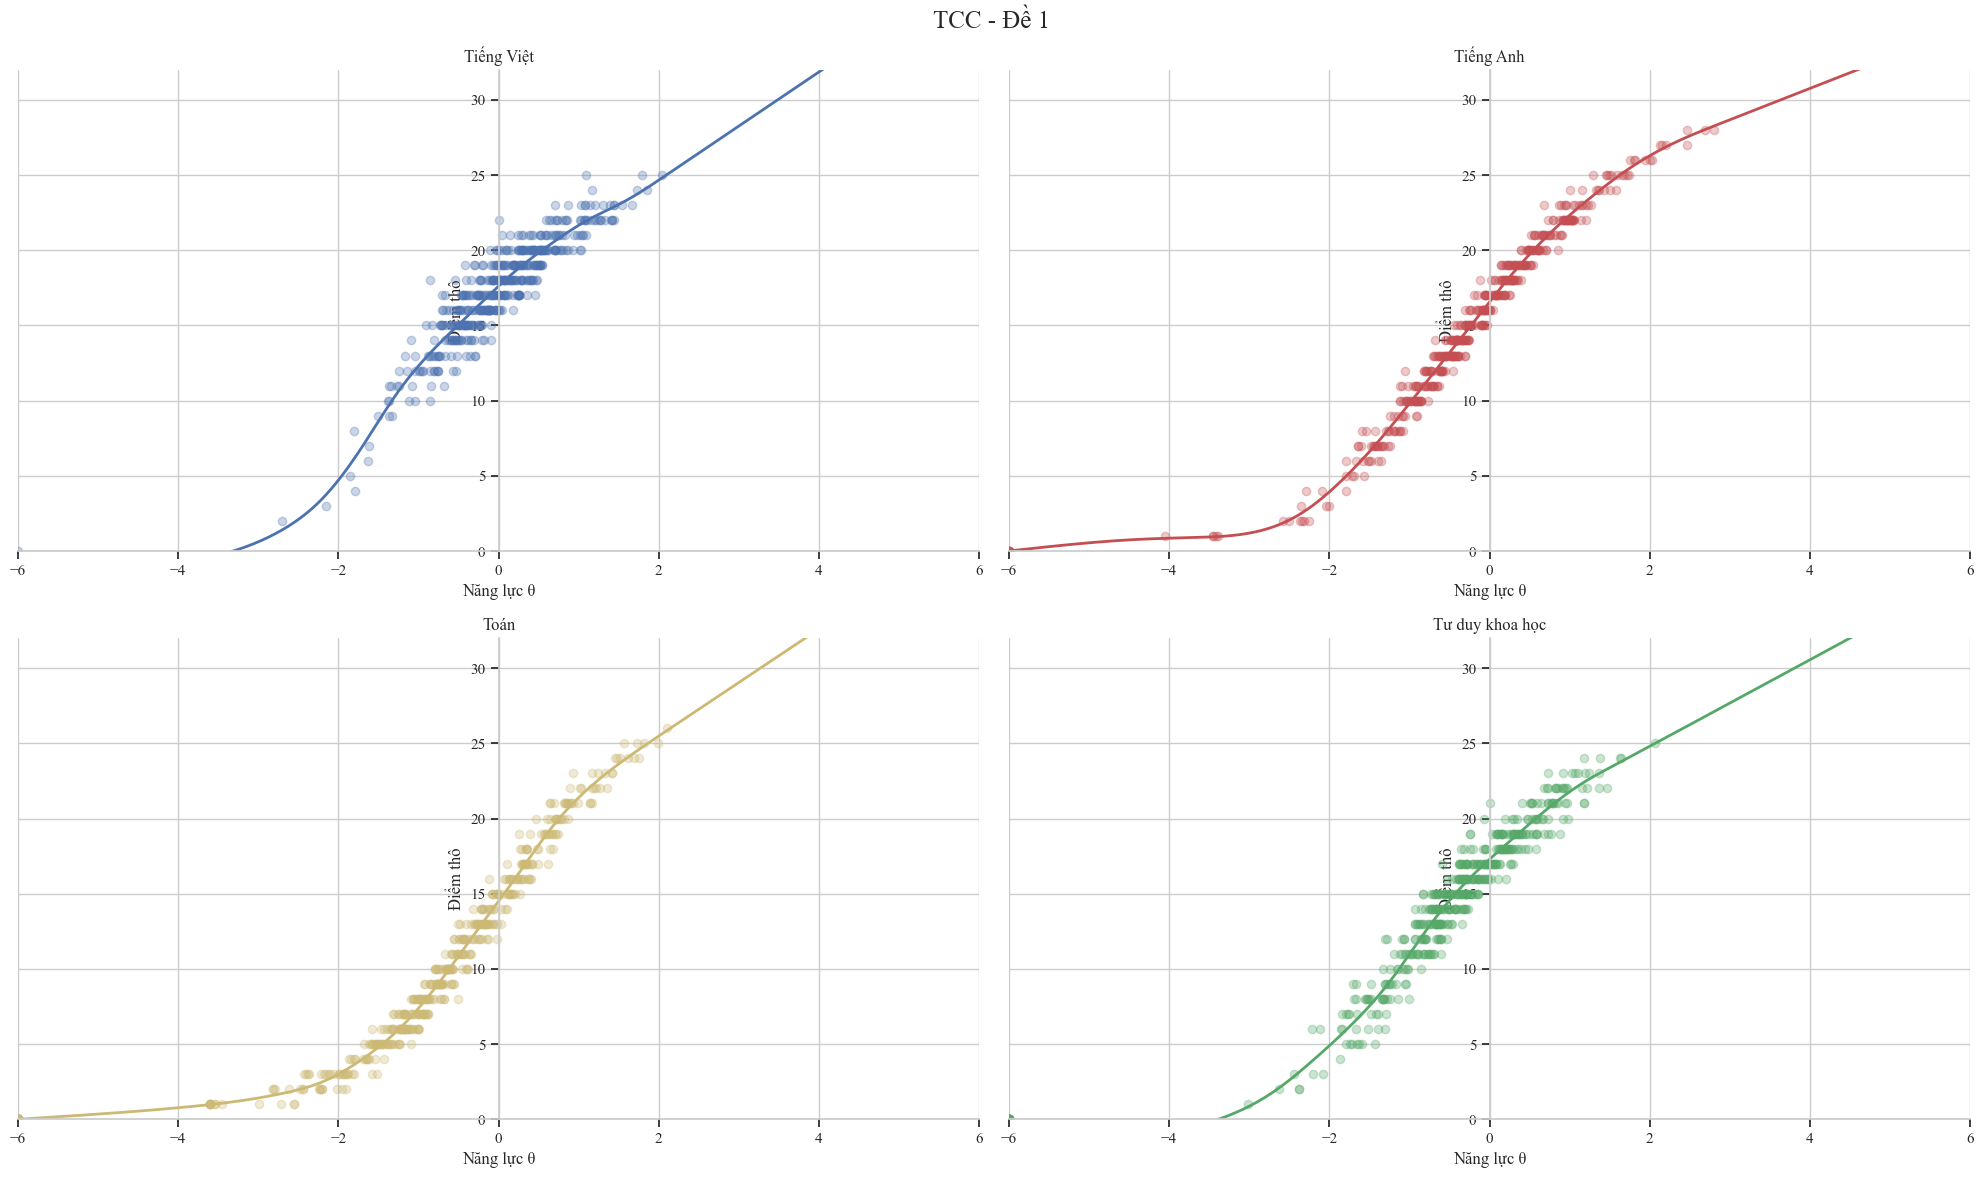

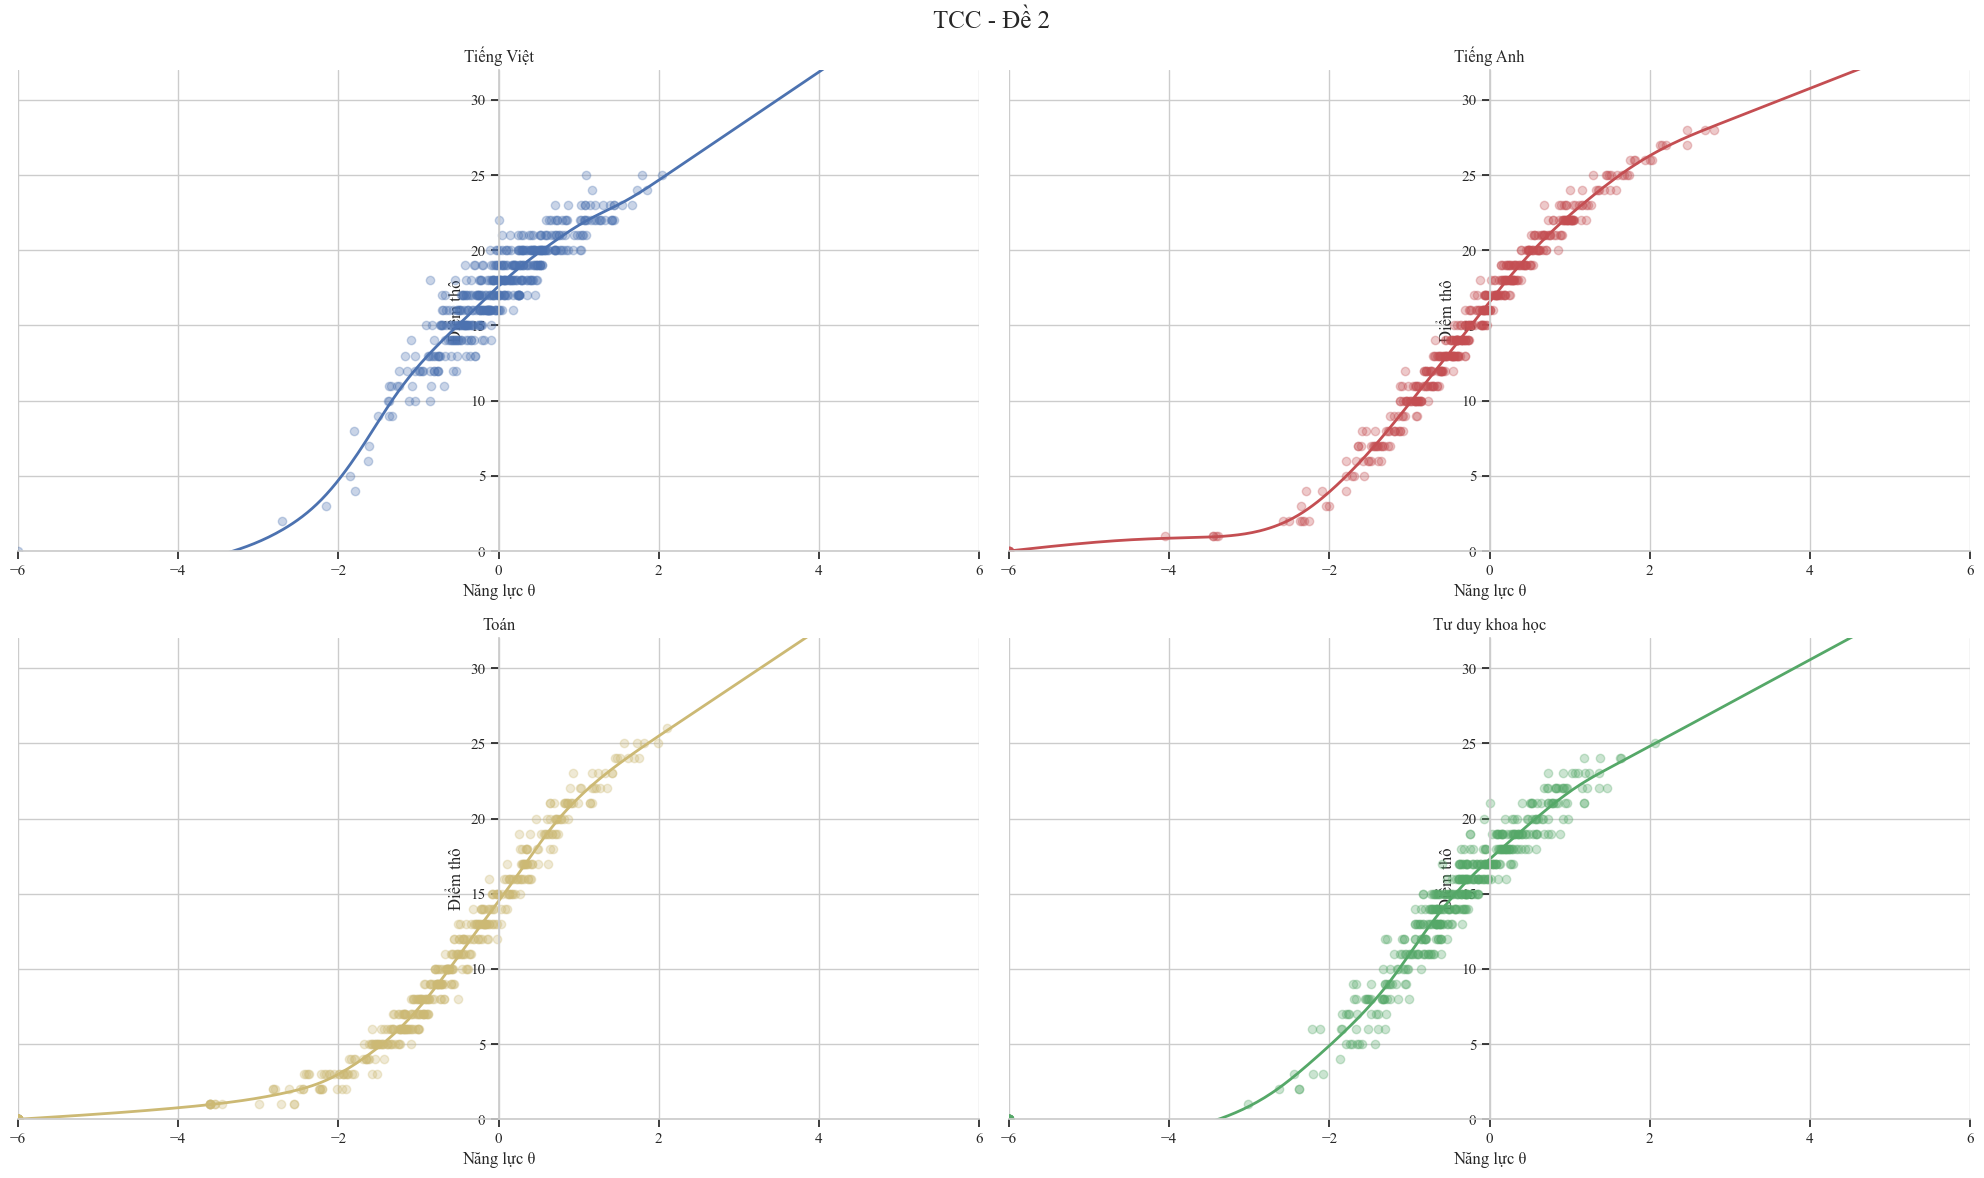

In [78]:
drawTTC(df_TV1, df_TA1, df_TO1, df_KH1, title="TCC - Đề 1")
drawTTC(df_TV1, df_TA1, df_TO1, df_KH1, title="TCC - Đề 2")

In [67]:
chi_square_1, chi_square_2 = pd.DataFrame(), pd.DataFrame()

for df_list in [df_TV1, df_TA1, df_TO1, df_KH1]:
    items = [c for c in df_list.columns if c.startswith("Cau")]
    start_item, end_item = items[0], items[-1]
    res = irt.chi_square(df_list[df_list['Null'] < 30], item_irt_1.loc[start_item:end_item]) # loại các trường hợp không thi 1 phần
    res.index = item_irt_1.loc[start_item:end_item].index
    chi_square_1 = pd.concat([chi_square_1, res], axis=0)

for df_list in [df_TV2, df_TA2, df_TO2, df_KH2]:
    items = [c for c in df_list.columns if c.startswith("Cau")]
    start_item, end_item = items[0], items[-1]
    res = irt.chi_square(df_list[df_list['Null'] < 30], item_irt_2.loc[start_item:end_item])
    res.index = item_irt_2.loc[start_item:end_item].index
    chi_square_2 = pd.concat([chi_square_2, res], axis=0)

item_irt_1 = pd.concat([item_irt_1, chi_square_1], axis=1)
item_irt_2 = pd.concat([item_irt_2, chi_square_2], axis=1)

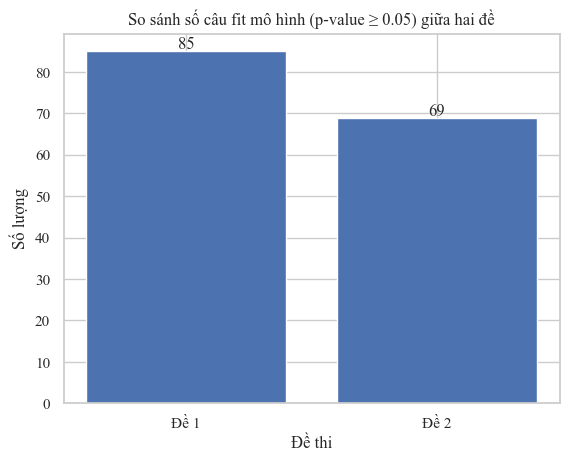

In [68]:
num_pvalue_1 = item_irt_1[item_irt_1['p_value']>=0.05].shape[0]
num_pvalue_2 = item_irt_2[item_irt_2['p_value']>=0.05].shape[0]

labels = ["Đề 1", "Đề 2"]
values = [num_pvalue_1, num_pvalue_2]

plt.bar(labels, values)
plt.xlabel("Đề thi")
plt.ylabel("Số lượng")
plt.title("So sánh số câu fit mô hình (p-value ≥ 0.05) giữa hai đề")
for i, v in enumerate(values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=12)
plt.show()


In [69]:
chi_square_1['Phân loại'] = (
    chi_square_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

chi_square_2['Phân loại'] = (
    chi_square_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

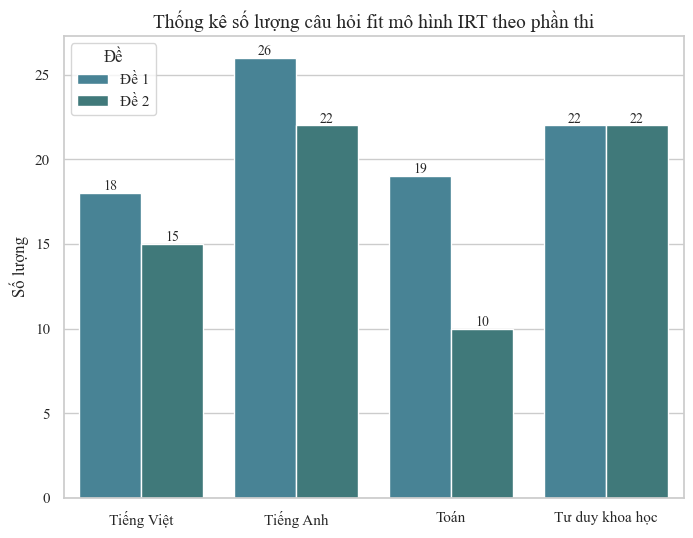

In [70]:
ip.plot_item(chi_square_1[chi_square_1['p_value']>=0.05], 
             chi_square_2[chi_square_2['p_value']>=0.05], 
             title='Thống kê số lượng câu hỏi fit mô hình IRT theo phần thi', order=['Tiếng Việt', 'Tiếng Anh', 'Toán', 'Tư duy khoa học'], palette='mako_d', size=(8,6))

In [71]:
for item_list in ([item_irt_1, item_irt_2]):
    ses = irt.all_item_se(item_list[['a', 'b']].to_numpy())
    item_list['a_SE'] = ses[:, 0]
    item_list['b_SE'] = ses[:, 1]

Text(0.5, 1.0, 'Sai số chuẩn ước lượng tham số các câu hỏi')

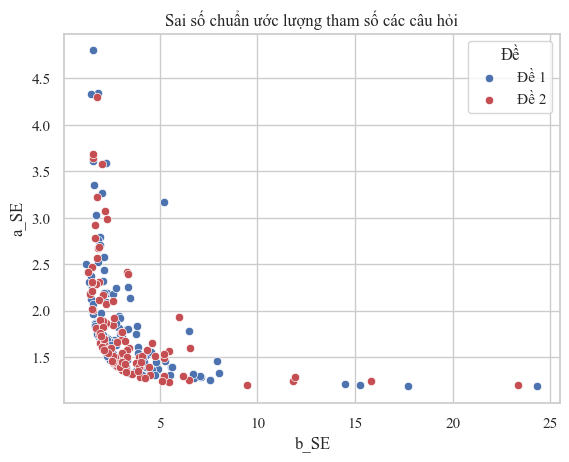

In [72]:
sns.scatterplot(data=item_irt_1, x='b_SE', y='a_SE', color='b', label='Đề 1')
sns.scatterplot(data=item_irt_2, x='b_SE', y='a_SE', color='r', label='Đề 2')
plt.legend(title='Đề')
plt.title("Sai số chuẩn ước lượng tham số các câu hỏi")

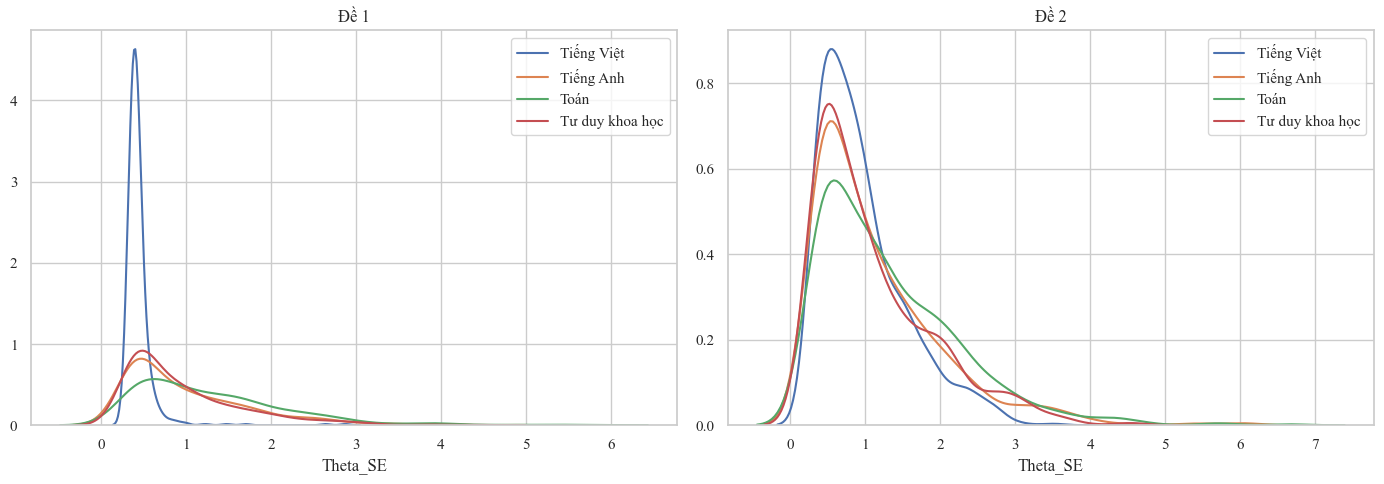

In [73]:
def plot_theta_se(df_list):
    items = [c for c in df_list.columns if c.startswith("Cau")]
    response = df_list[items].replace(-1, 0)
    se = irt.all_ability_se(
        response.to_numpy(),
        item_irt_1.loc[items][['a', 'b']].to_numpy(),
        df_list['Theta'][df_list['Null'] < 30].to_numpy()
    )
    return se


list_names = [
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học" ],
    ["Tiếng Việt", "Tiếng Anh", "Toán", "Tư duy khoa học" ]
]

all_df_groups = [
    [df_TV1, df_TA1, df_TO1, df_KH1],
    [df_TV2, df_TA2, df_TO2, df_KH2]
]

# --- tạo subplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_group, names, title in zip(
    axes,
    all_df_groups,
    list_names,
    ["Đề 1", "Đề 2"]
):
    for df, name in zip(df_group, names):
        se = plot_theta_se(df)
        sns.kdeplot(se, label=name, ax=ax)

    ax.set_xlabel("Theta_SE")
    ax.set_ylabel(None)
    ax.set_title(title)
    ax.legend()
    
plt.tight_layout()
plt.show()


In [168]:
df_survey=pd.read_excel('KhaoSat_Cleaned.xlsx')
df_survey

,Mail,TO10_1,TV10_1,TA10_1,TO10_2,TV10_2,TA10_2,TO11_1,TV11_1,TA11_1,TO11_2,TV11_2,TA11_2
0,giaminh4207@gmail.com,7.9,8.5,7.8,8.1,8.6,8.0,8.6,8.8,7.7,8.5,8.7,7.5
1,muoidayn@gmail.com,9.1,7.3,8.1,9.3,7.0,8.0,9.5,7.5,8.3,9.6,7.3,8.0
2,botbmt719@gmail.com,7.9,8.1,8.2,7.9,8.1,8.2,8.5,8.1,8.7,8.5,8.1,8.7
3,nq739910@gmail.com,6.5,8.2,8.5,7.0,8.6,8.4,8.7,8.2,8.9,8.9,8.6,8.4
4,vikhang532@gmail.com,8.5,9.1,8.8,8.6,8.9,8.5,8.2,8.3,8.8,8.8,9.1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,perriznguyen16@gmail.com,7.3,6.5,8.2,9.2,7.3,9.0,6.8,7.2,9.0,8.6,7.3,7.5
461,baohuy.160420071@gmail.com,7.0,9.0,6.0,8.0,9.0,7.0,7.0,9.0,6.0,7.0,8.0,7.0
462,tidiphan28@gmail.com,7.0,9.0,7.0,7.0,8.5,6.5,7.5,9.0,6.5,7.0,8.0,6.0
463,trantrungtin2008114@gmail.com,6.7,7.5,6.3,9.0,7.7,7.3,8.4,7.1,8.2,9.4,6.8,8.2


In [169]:
thi_sinh = pd.concat([thisinh_both, thisinh_only1, thisinh_only2])

In [170]:
thi_sinh

0       tuyetnhung01111999@gmail.com
1            hahahihi51108@gmail.com
2      trucphuongcutiis1tg@gmail.com
3          trankhoafbbaoho@gmail.com
4                 pttn1501@gmail.com
                   ...              
500          luukienluubui@gmail.com
501      nhatcuongnguyenle@gmail.com
502          minhduy123838@gmail.com
503            pkl24092000@gmail.com
504          vikhangluuanh@gmail.com
Length: 974, dtype: object

In [171]:
thi_sinh.index = thi_sinh.index.astype(str)

In [172]:
df_survey_copy = df_survey.merge(thi_sinh.rename('Mail'), how='right', left_on='Mail', right_on='Mail')

In [173]:
df_survey

,Mail,TO10_1,TV10_1,TA10_1,TO10_2,TV10_2,TA10_2,TO11_1,TV11_1,TA11_1,TO11_2,TV11_2,TA11_2
0,giaminh4207@gmail.com,7.9,8.5,7.8,8.1,8.6,8.0,8.6,8.8,7.7,8.5,8.7,7.5
1,muoidayn@gmail.com,9.1,7.3,8.1,9.3,7.0,8.0,9.5,7.5,8.3,9.6,7.3,8.0
2,botbmt719@gmail.com,7.9,8.1,8.2,7.9,8.1,8.2,8.5,8.1,8.7,8.5,8.1,8.7
3,nq739910@gmail.com,6.5,8.2,8.5,7.0,8.6,8.4,8.7,8.2,8.9,8.9,8.6,8.4
4,vikhang532@gmail.com,8.5,9.1,8.8,8.6,8.9,8.5,8.2,8.3,8.8,8.8,9.1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,perriznguyen16@gmail.com,7.3,6.5,8.2,9.2,7.3,9.0,6.8,7.2,9.0,8.6,7.3,7.5
461,baohuy.160420071@gmail.com,7.0,9.0,6.0,8.0,9.0,7.0,7.0,9.0,6.0,7.0,8.0,7.0
462,tidiphan28@gmail.com,7.0,9.0,7.0,7.0,8.5,6.5,7.5,9.0,6.5,7.0,8.0,6.0
463,trantrungtin2008114@gmail.com,6.7,7.5,6.3,9.0,7.7,7.3,8.4,7.1,8.2,9.4,6.8,8.2


In [174]:
df_true_1_copy, df_true_2_copy = df_true_1.copy(), df_true_2.copy()

In [175]:
df_true_1_copy = df_true_1_copy.merge(df_dot1[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')
df_true_2_copy = df_true_2_copy.merge(df_dot2[['SBD', 'Email']], how='left', left_on='SBD', right_on='SBD')

In [176]:
df_true_1_copy = df_true_1_copy.merge(df_survey, how='right', left_on='Email', right_on='Mail').dropna().drop(columns=['Mail', 'SBD']).set_index('Email')
df_true_2_copy = df_true_2_copy.merge(df_survey, how='right', left_on='Email', right_on='Mail').dropna().drop(columns=['Mail', 'SBD']).set_index('Email')

In [188]:
df_true_1_copy.shape[0], df_true_2_copy.shape[0]

(188, 328)

In [189]:
from scipy.stats import pearsonr
import numpy as np

def calculate_correlations(df_true):
    correlations = {}
    subjects = ['TV', 'TA', 'TO']
    semesters = ['10_1', '10_2', '11_1', '11_2']

    for subject in subjects:
        score_col = f'True{subject}'
        for sem in semesters:
            subject_col = f'{subject}{sem}'

            x = df_true[score_col]
            y = df_true[subject_col]

            # Loại bỏ NaN
            mask = (~x.isna()) & (~y.isna())
            x_valid = x[mask]
            y_valid = y[mask]

            if len(x_valid) < 2:
                correlations[f'{score_col} vs {subject_col}'] = None
                continue

            corr, _ = pearsonr(x_valid, y_valid)
            correlations[f'{score_col} vs {subject_col}'] = round(corr, 4)

    return correlations


def print_correlations(title, corr_dict):
    print(title)
    for key, value in corr_dict.items():
        print(f'{key}: {value}')
    print()  # dòng trống cuối


corr1 = calculate_correlations(df_true_1_copy)
corr2 = calculate_correlations(df_true_2_copy)

print_correlations("Hệ số tương quan đề 1:", corr1)
print_correlations("Hệ số tương quan đề 2:", corr2)

Hệ số tương quan đề 1:
TrueTV vs TV10_1: 0.1671
TrueTV vs TV10_2: 0.1471
TrueTV vs TV11_1: 0.0924
TrueTV vs TV11_2: 0.0953
TrueTA vs TA10_1: 0.4194
TrueTA vs TA10_2: 0.4182
TrueTA vs TA11_1: 0.4444
TrueTA vs TA11_2: 0.4544
TrueTO vs TO10_1: 0.3188
TrueTO vs TO10_2: 0.3243
TrueTO vs TO11_1: 0.2328
TrueTO vs TO11_2: 0.2712

Hệ số tương quan đề 2:
TrueTV vs TV10_1: 0.1263
TrueTV vs TV10_2: 0.1811
TrueTV vs TV11_1: 0.1448
TrueTV vs TV11_2: 0.1518
TrueTA vs TA10_1: 0.3209
TrueTA vs TA10_2: 0.2949
TrueTA vs TA11_1: 0.3316
TrueTA vs TA11_2: 0.3387
TrueTO vs TO10_1: 0.329
TrueTO vs TO10_2: 0.3057
TrueTO vs TO11_1: 0.2962
TrueTO vs TO11_2: 0.2782

